# `I Compressed Sensing (CS) of Images`
Ce notebook explore l’acquisition comprimée (compressed sensing) d’images, en évaluant plusieurs modèles de parcimonie des coefficients dans une base d’ondelettes, afin d’améliorer la qualité de reconstruction avec un nombre réduit de mesures.

La théorie du compressed sensing s’appuie sur l’idée que l'on peut reconstruire un signal à partir de beaucoup moins de mesures que sa dimension, à condition qu’il soit parcimonieux c-a-d que la plupart de ses coefficients soient nuls dans une base adaptée.
## `1.1 Cadre de base`
On observe un **signal** $m \in \mathbb{R}^N$ `via des mesures linéaires` tel que :
$\Large y = A m \text{ <> } \Large y = A(\Psi^{-1}x)$
Les composantes de $\large \mathbb y$ représentent les mesures physiques issues d'un dispositif d’acquisition (combinaisons linéaires de pixels). Dans ce régime ou $len(y)=M$, $M≪N$, le système est sous‑déterminé car il existe une infinité de $\large \mathbb m$ compatibles avec $\large \mathbb y$. La matrice $\large \mathbb A$ décrit comment l’appareil de mesure combine les composantes de $m$ (optique, capteur, ...etc.).
- N dimension du signal (longueur du vecteur ou nombre de pixels)
- M nombre de mesures (nombre de lignes de A)
- $\large \mathbb m \in R^N$ le signal dans le domaine original (image, son, etc.)
- $A \in \mathbb{R}^{M \times N}$ est une matrice de mesure et $M \ll N$
- $\large \mathbb y \in R^M$ vecteur de mesures 
Les “coefficients” sparsifiés désignent les composantes de $x = \Psi m $ dans une base adaptée (ondelettes, etc.), sur lesquelles on impose la parcimonie.
$\Large x = \Psi m \text{ <=> } \Large m = \Psi^{-1} x$
- $x$ le signal sparse, c’est‑à‑dire ses coefficients dans la base $\Psi$ (ondelettes, Fourier, …),.
- $\Psi$ transforme le signal $m$ en représentation sparse $x$ (ondelettes, Fourier, etc,).
- $m\in R^N$ le signal dans le domaine original (image, son, etc.)
- $\Psi^{-1}$ opérateur inverse qui reconstruit $m$ à partir de $x$.

## `1.2 Rôle de la parcimonie`
La parcimonie sert à sélectionner, parmi toutes les solutions compatibles avec les mesures, celle dont la représentation $x$ dans la base $\Psi$ est la plus “rare” (peu de coefficients non nuls).
- On souhaiterait résoudre : $ \min_{x} \|x\|_0 \text{ sous la contrainte } \large  y = A \Psi^{-1} x$
Mais ce problème en $\ell_0$ est combinatoire et NP‑difficile, 
- On le remplace donc par $ \min_{x} \|x\|_1$  sous la contrainte $ y = A \Psi^{-1} x$  convexe sous hypothèses appropriées sur A

La minimisation en norme $\ell_1$ permet de retrouver la solution parcimonieuse, même lorsque $M \ll N$.
- l’astuce de CS est d’ajouter l’hypothèse de parcimonie sur le signal, 
- on suppose qu’il admet une représentation $x = \Psi.m$, dans une base ou dictionnaire $\Psi$, 
- $x$ est K‑parcimonieux, si le vecteur $x$ ne possède qu'un petit nombre $K$ de coefficients non nuls, 
- tel qu'écrit $x = \Psi.\alpha$ avec $\alpha$ ayant peu de coefficients significatifs dans une base $\Psi$.

### `1.2.1 Intuition pour les images naturelles`
Pour une image $m$, on prend souvent $x = \Psi \alpha$ avec $\Psi$ base d’ondelettes, car :
- les images naturelles ont des coefficients d’ondelettes qui décroissent vite avec l’échelle.  
- elles sont bien approchées par un **petit nombre** de coefficients significatifs (bords, contours),
- donc $\alpha$ est parcimonieux ou compressible. 
__Nous pouvons donc :__
1. Mesurer directement $y = A.m$ avec $M \ll N$.  
2. Reconstruire $\hat m$ en résolvant un problème de minimisation $\ell_1$ sur les coefficients ondelettes. 
#### _`Synthèse`_
On cherche à reconstruire un signal $x∈R^N$ à partir d’un nombre de mesures linéaires $M≪N$, données par $y=Ax$. 
_`La clé est l’hypothèse de parcimonie suppose que:`_ 
- $x$ est sparse ou compressible dans une base adaptée, c-a-d qu’il peut s’écrire $x=\Phi\alpha$ 
- avec un vecteur de coefficients $\alpha$ comportant peu de composantes significatives. 
- sous des hypothèses appropriées sur la matrice de mesure $A$ (incohérence, propriété de type RIP),
- on peut retrouver $x$ en résolvant un problème de minimisation de norme $\ell_1$ sur les coefficients $\alpha$, 
- permettant une reconstruction fidèle malgré un sous‑échantillonnage important.

In [1]:
import sys, os
import numpy as np
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

from nt_toolbox.general import *
from nt_toolbox.signal import *
import nt_toolbox as nt

%matplotlib inline
%load_ext autoreload
%autoreload 2

# `2 Filtre "passe-bas" mesures linéaires`

- La transformée de Fourier donne une distribution des fréquences sur l'ensemble du domaine temporelle. 
- Par conséquence que les fréquences soit simultanées ou différées la transformée de Fourier le capte peu. 
- La transformée de Fourier ignore les effets de localité spatiale ou temporelle dans un signal. 
- La transformée en Ondelette permet de s'attaquer a ce type de problème. 
- La ou la transformée de Fourier est une transformation en fréquence, 
- La transformée en ondelette est une transformation temps-fréquence ou espace-fréquence.

## `2.1 Contexte`

`Utiliser les mesures d'un filtre "pass-bas" pour retirer les basses fréquences de l'image`.
 - les images naturelles ne sont pas seulement parcimonieuses dans le domaine des ondelettes. 
 - elles présentent également une décroissance rapide des coefficients au fil des échelles. 
 - la graine d'ondelette grossières (passe-bas) concentrent une grande partie de l’énergie de l’image.
 - il est donc pertinent de mesurer directement les coefficients "pass-bas"
`Opérationnellement : `
 - cela revient à appliquer une décomposition en ondelettes, 
 - à extraire les coefficients d’approximation de niveau grossier, 
 - on met à zéro les coefficients $C_A$ d'approximation issus du passe‑bas.
 - puis à annuler ces coefficients lors de la reconstruction pour obtenir une image sans basses fréquences. » 

Maintenant nous chargeons une image $m \in \mathcal{R}^{n^2}$ de $n \times n$ pixels.

(256, 256)


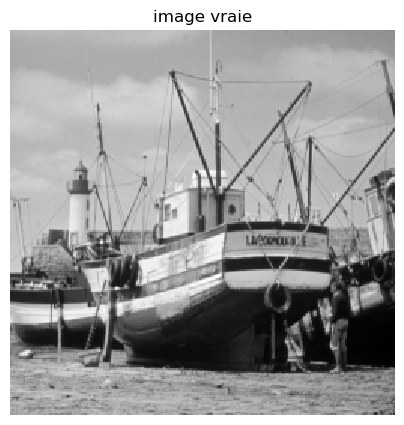

In [2]:
path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/boat.bmp'

n = 256 # 512

f0 = load_image(name,n)          # f0.shape = (256, 256)
f0 = (f0 - f0.min()) / (f0.max() - f0.min() + 1e-12)
print(f0.shape)

from skimage.transform import rescale

#f0= rescale(f0, scale=0.5, anti_aliasing=True)   # par ex. moitié moins grand
plt.figure(figsize=(5, 5))
imageplot(clamp(f0),'image vraie')


## `2.2 Principe`
`Raccourci pour les transformés en ondelettes` $\{ \langle f, \Psi_m \rangle \}_m$
- Nous calculons la transformée jusqu'à l'échelle $J$ de sorte que seuls les sous-bandes $k_0$ sont transformées.
- Les coefficients d’ondelettes sont des produits scalaires entre le signal et des “briques” de base.

Définition de $P_f$ opérateur de projection passe‑bas sur l’espace d’approximation d’échelle J en fonction des coefficients d’approximation ondelettes $\Phi_{J,k}$ :
-  $P_f=\sum_k⟨f,\Phi_{J,k} ⟩\Phi_{J,k})$ et son lien avec la primitive wavedec2 

Mathématiquement, nous avons une décomposition du type où : 
- $\large f(t) = \sum_{k} cA_J[k]\,\phi_{J,k}(t) + \sum_{j=1}^{J} \sum_{k} cD_j[k]\,\psi_{j,k}(t)$

  - $\Phi_{J,k}$ sont les fonctions d’échelle
  - $\Psi_{j,k}$ les ondelettes.
  - cA_J le premier bloc concatèné correspond aux coefficients d'approximation grossier basse fréquences.
  - cD_1, cD_2,.., cD_J sont les blocs suivants sont les coefficientsde détails de plus en plus grossiers suivant l'ordre.

Sert à fixer la plus petite échelle de la transformée en ondelettes, jusqu’à où descendre dans les décompositions en résolution.

`Que représente un coefficient`
Pour chaque échelle J et la position k :
- $\Phi_{J,k}(t)$ : une fonction d’échelle (low-pass) centrée près de la position k, à l’échelle grossière J.
- $\Psi_{j,k}(t)$ : une ondelette (petite oscillation localisée) à l’échelle J et position k.

Avec Discrete Wavelet Transform 1D, les coefficients [cA_J, cD_J, cD_{J-1}, ..., cD_1] obtenus ont pour signification : 
`cA_J :` 
- coefficients d’approximation au niveau le plus grossier J. 
- ce sont les projections du signal sur les fonctions d’échelle (low-pass), 
- donc le contenu “lent”, les grandes structures / tendance globale.

`cD_j :` 
- coefficients de détail au niveau j. 
- ce sont les projections sur les ondelettes à l’échelle $2^j$, 
- donc le contenu “rapide” autour de cette échelle, variations locales, détails, singularités.

Intuition par niveau :
- `cD_1` : détails les plus fins (hautes fréquences, bruit, petits bords).
- `cD_2` : un peu plus grossier, etc.
- `cD_J` : détails relativement grossiers, structures un peu plus larges.
- `cA_J` : ce qui reste après avoir filtré tous ces détails, une version très lissée du signal.

### `2.2.1 Transformée en ondelettes discrètes 2D directe et inverse` 

In [3]:
import pywt
wavelet = pywt.DiscreteContinuousWavelet('db2')
print(wavelet)

Wavelet db2
  Family name:    Daubechies
  Short name:     db
  Filters length: 4
  Orthogonal:     True
  Biorthogonal:   True
  Symmetry:       asymmetric
  DWT:            True
  CWT:            False


In [4]:
import numpy as np

# perform_direct_wavelet_transf transformée directe est un opérateur  
# qui prend une image et retourne la structure des coefficients d’ondelettes.
# Cette version est adaptée si tu fais juste du forward/inverse sans transformer 
# les coeffs en gros vecteur pour les mettre dans un solveur générique.
def direct_wavelet_transf(img,level,wavelet='db2'):
    coeffs_ti_2d = pywt.wavedec2(img, wavelet=wavelet, level=level, mode='periodization')
    return coeffs_ti_2d

# coeffs_ti_2d : version “hiérarchique” par niveau (ce que voit waverec2).
# coeffs_arr : version “aplatie” dans un seul array pour manipulations/visualisation.
# coeffs_slices : la carte qui relie les deux formats (pour couper/reconstituer correctement).

# perform_inverse_wavelet_transf l’opérateur inverse qui à partir des coefficients d’ondelettes, 
# reconstruit l’image, en appelant.
def inverse_wavelet_transf(coeffs_ti_2d,wavelet='db2'):
    f_rec = pywt.waverec2(coeffs_ti_2d, wavelet=wavelet, mode='periodization')
    return f_rec

# reconstruction depuis les coefficient d'ondelette
# Cette version est faite pour les situations où l'on veut travailler avec 
# un vecteur/array aplati de coefficients (pour du PG, ISTA, FISTA, etc.) 
# et revenir ensuite à la structure PyWavelets
def wv2d_inverse(coeffs_arr, coeffs_slices, wavelet='db2'):
    coeffs = pywt.array_to_coeffs(coeffs_arr, coeffs_slices, output_format='wavedec2')
    img = pywt.waverec2(coeffs, wavelet=wavelet)
    return img

### `2.2.2 Calculer la transformée en ondelette.`

In [5]:
coeffs_ti_2d = direct_wavelet_transf(f0,level=3)
# Approximation au niveau le plus grossier
cA = coeffs_ti_2d[0]
print(f"cA_J : {cA.shape}, len(coeffs_ti_2d[1:] : {len(coeffs_ti_2d[1:])}), len(coeffs_ti_2d) : {len(coeffs_ti_2d)}\n")
# Détails : du niveau J jusqu'au niveau 1
for j, (cH, cV, cD) in enumerate(coeffs_ti_2d[1:], start=1):
    level = len(coeffs_ti_2d) - j   # juste pour numéroter J, J-1, ..., 1
    print(f"n: {n}, j: {j} Level {level}: cH_{level} {cH.shape}, cV_{level} {cV.shape}, cD_{level} {cD.shape}")

cA_J : (32, 32), len(coeffs_ti_2d[1:] : 3), len(coeffs_ti_2d) : 4

n: 256, j: 1 Level 3: cH_3 (32, 32), cV_3 (32, 32), cD_3 (32, 32)
n: 256, j: 2 Level 2: cH_2 (64, 64), cV_2 (64, 64), cD_2 (64, 64)
n: 256, j: 3 Level 1: cH_1 (128, 128), cV_1 (128, 128), cD_1 (128, 128)


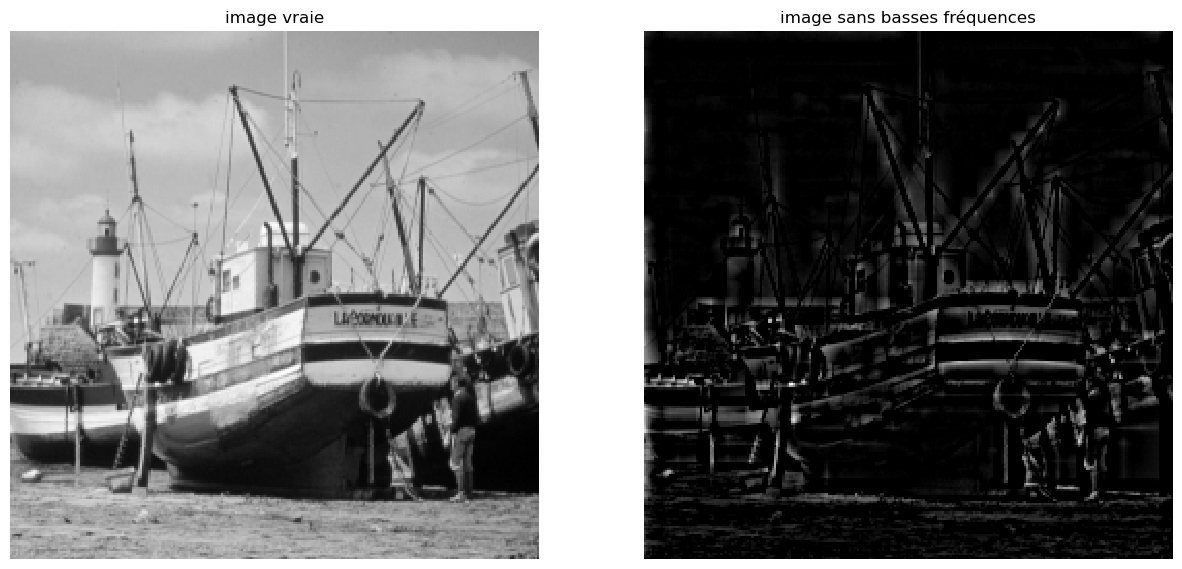

In [6]:
# Mise à zéro de cA (basses fréquences)
cA, details = coeffs_ti_2d[0], coeffs_ti_2d[1:]
cA_zero = np.zeros_like(cA)
coeffs_high = [cA_zero] + list(details)
f_vec = inverse_wavelet_transf(coeffs_high)
plt.figure(figsize=(15, 15))
imageplot(clamp(f0),'image vraie',[1,2,1])
imageplot(clamp(f_vec),'image sans basses fréquences',[1,2,2])

### `2.2.3 Résultat`

- LL = approximation → tons clairs uniformes (ciel, murs lisses)
- LH = contours verticaux  → hautes fréquences
- HL = contours horizontaux → hautes fréquences  
- HH = contours diagonaux   → hautes fréquences

On décompose l’image par ondelettes, ensuite nous annulons les coefficients d’approximation (passe‑bas), puis on reconstruit à partir des seuls coefficients de détail. Le résultat est une image où la composante basse fréquence a été retirée, ne laissant visibles que les structures de haute fréquence (contours, textures).

# `3. Exercice 1`
Construire une approximation basse fréquence $∣f_{low}∣$ 
- Ne conserver que les coefficients passe‑bas, au nombre de $P=2^{2^J} =(n/k_0)^2$ : 
  - image est de taille $n×n$.
  - on travaille avec une décomposition ondelette 2D à $J=log2(n)−k0$ niveaux.
  - au niveau le plus grossier, le bloc basse fréquence (cA_J) est de taille $(n/2^{k_0})×(n/2^{k_0})$.
  - si on note $2^{k_0}=k_0$ => $(n/2^{k_0})×(n/2^{k_0}) \equiv (n/{k_0})^2$ => $P=2^{2^J} =(n/k_0)^2$
  - P correspond au nombre de coefficients passe‑bas utilisés pour construire $f_{low}$

cA.shape : (32, 32), 64*64 : 4096, f_low.shape : (256, 256)


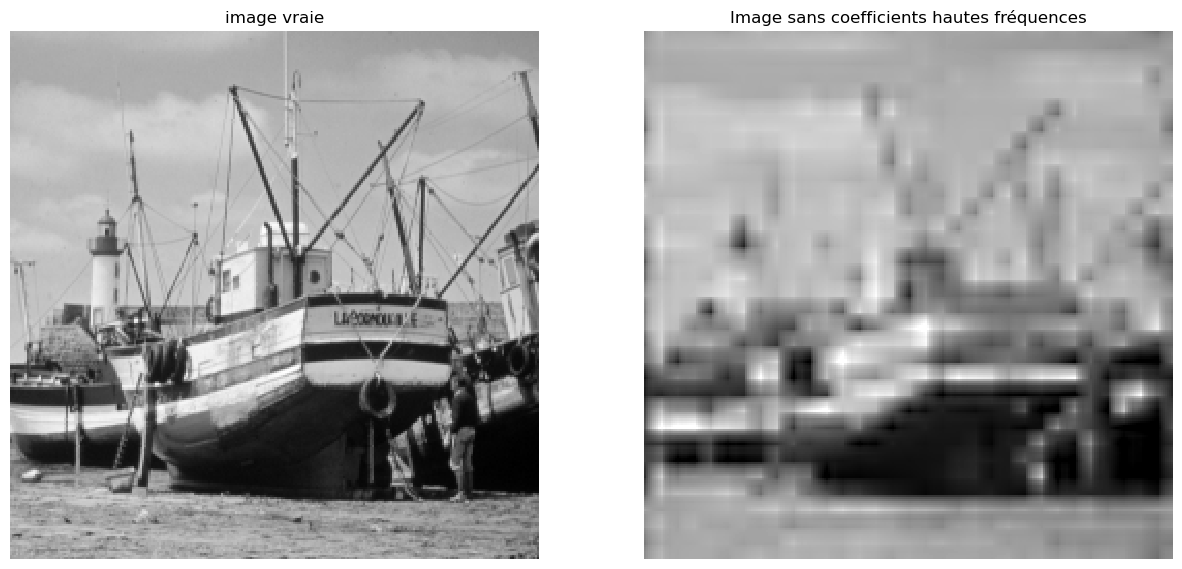

In [7]:
details_zero = [(np.zeros_like(cH), np.zeros_like(cV),np.zeros_like(cD)) for (cH, cV, cD) in details]
coeffs_low = [cA] + details_zero
f_low = inverse_wavelet_transf(coeffs_low)
print(f"cA.shape : {cA.shape}, 64*64 : {64*64}, f_low.shape : {f_low.shape}")
plt.figure(figsize=(15, 15))
imageplot(clamp(f0),'image vraie',[1,2,1])
imageplot(clamp(f_low),f'Image sans coefficients hautes fréquences',[1,2,2])


## `3.1 Mesures orthogonales aléatoires`.
- Considérons un opérateur "compressed sensing" qui correspond à une projection orthogonal randomisée.
- Extraire les coefficients d'ondelettes haute-fréquences $x_0 = \{ \langle f, \psi_m \rangle \}_{m \in I_0}$.
   - A est un masque $n×n$ rempli de 1.
   - on met à 0 le bloc supérieur gauche de taille $2^J×2^J$
   - A == 0 = zone low-pass, 
   - A == 1 = zone high-pass

<table border="1" style="border-collapse:collapse; text-align:center; font-family:monospace;">
  <tr>
    <td style="width:30px; height:30px;">0<br><small>LL</small></td>
    <td style="width:30px; height:30px;">1<br><small>LH</small></td>
    <td rowspan="2" style="width:60px; height:60px;">1<br><small>LH</small></td>
  </tr>
  <tr>
    <td style="width:30px; height:30px;">1<br><small>HL</small></td>
    <td style="width:30px; height:30px;">1<br><small>HH</small></td>
  </tr>
  <tr>
    <td colspan="2" style="width:60px; height:60px;">1<br><small>HL</small></td>
    <td style="width:60px; height:60px;">1<br><small>HH</small></td>
  </tr>
</table>
<div>
</div>

| Zone                                           | Valeur dans A | Rôle                             |
| ---------------------------------------------- | ------------- | -------------------------------- |
| Bloc $2^J \times 2^J$ en haut à gauche | 0             | Low-pass (exclus de $I_0$)    |
| Tout le reste                                  | 1             | High-pass (inclus dans $I_0​$) |

### `3.1.1 Extrait du vecteur de coefficients d'ondelettes haute-fréquence` 
$$\large x_0={⟨f,ψ.m⟩}m∈I_0$$
- `pywt.coeffs_to_array` reconstruit l'image de coefficients (n x n) d'un coup et retourne : 
- `fw_img :`Recolle toutes les sous-bandes en une seule image 2D
- `slices :`Retourne les positions de chaque sous-bande dans fw_img

In [8]:
# Reconstruire l'image de coefficients (n x n) d'un coup
# fw_img — Recolle toutes les sous-bandes en une seule image 2D
# slices — Retourne les positions de chaque sous-bande dans fw_img
coeffs_arr, coeffs_slices = pywt.coeffs_to_array(coeffs_ti_2d)
A = np.ones((coeffs_arr.shape))  
A[0:coeffs_slices[0][0].stop,0:coeffs_slices[0][1].stop] = 0
# retourne les indices de la matrice ou se trouvent les coefficients hautes fréquences
I0 = np.where(A.flatten()==1)[0]
x0 = coeffs_arr.flatten()[I0]

print(f"low_h : {coeffs_slices[0][0].stop}, low_w : {coeffs_slices[0][1].stop}  => {coeffs_slices[0][0].stop**2}")
print(f"A.shape : {A.shape} => {A.flatten().shape}")
print(f"I0.shape : {I0.shape} => len(I0)+low_h**2 : {len(I0)+coeffs_slices[0][0].stop**2}")
print(f"Nombre de niveaux : {len(coeffs_ti_2d) - 1}, fw_img.shape : {coeffs_arr.shape}, {coeffs_arr.shape[0]*coeffs_arr.shape[0]} , A.shape : {A.shape}, I0.shape : {I0.shape}")
print(f"n: {n}, le nombre de coefficients haute fréquence est : {len(x0)}, (len(x0)+low_h**2) : {len(x0)+coeffs_slices[0][0].stop**2}")

low_h : 32, low_w : 32  => 1024
A.shape : (256, 256) => (65536,)
I0.shape : (64512,) => len(I0)+low_h**2 : 65536
Nombre de niveaux : 3, fw_img.shape : (256, 256), 65536 , A.shape : (256, 256), I0.shape : (64512,)
n: 256, le nombre de coefficients haute fréquence est : 64512, (len(x0)+low_h**2) : 65536


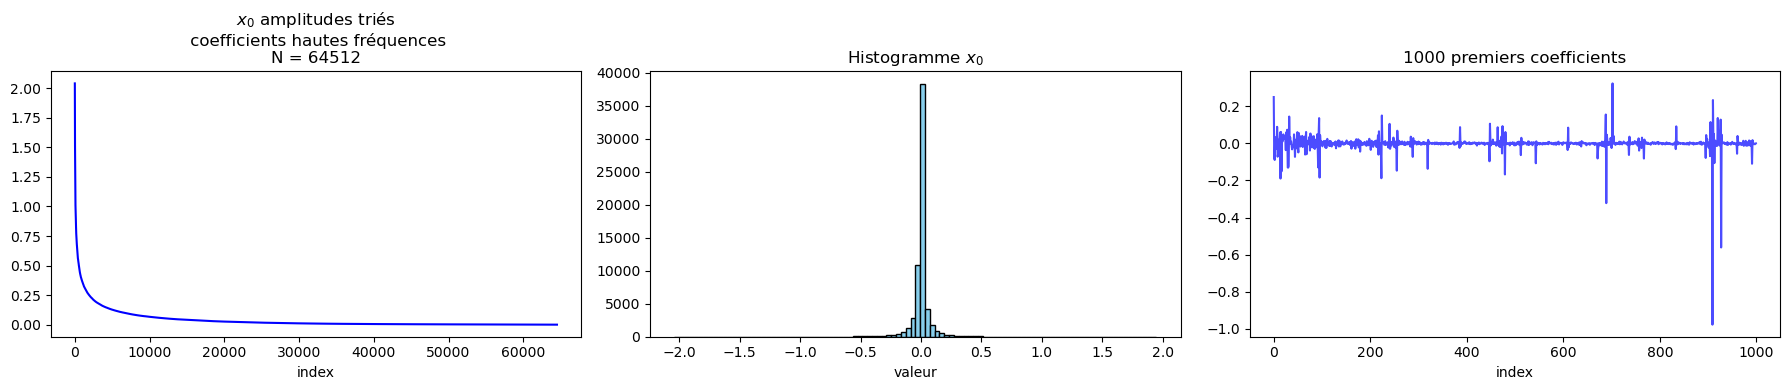

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Amplitudes triées
axes[0].plot(np.sort(np.abs(x0))[::-1], 'b-')
axes[0].set_title(f'$x_0$ amplitudes triés\n coefficients hautes fréquences\nN = {len(x0)}')
axes[0].set_xlabel('index')

# 2. Histogramme
axes[1].hist(x0, bins=100, color='skyblue', edgecolor='k')
axes[1].set_title(f'Histogramme $x_0$')
axes[1].set_xlabel('valeur')

# 3. Zoom sur les 1000 premiers
axes[2].plot(x0[:1000], 'b-', alpha=0.7)
axes[2].set_title(f'1000 premiers coefficients')
axes[2].set_xlabel('index')

plt.tight_layout()
plt.show()

### `3.1.2 Résultat`
- `Figure 1:` Amplitudes triées est la plus importante en Compressed Sensing car elle montre visuellement que peu de coefficients haute fréquence ont une grande amplitude (les premiers à gauche), la grande majorité des 61440 coefficients sont quasi nuls → Parcimonie confirmée : $x_0$ est bien sparse !

- `Figure 2:` Pic très marqué autour de 0 → la grande majorité des coefficients sont quasi nuls, confirmant la parcimonie vue dans la figure 1.

- `Figure 3:` Les coefficients oscillent autour de 0 avec quelques pics occasionnels. C'est typique des coefficients d'ondelettes où la plupart sont proches de 0, seuls quelques-uns (les contours de l'image) ont une amplitude significative.

## `3.2 Nombre de CS (acquisition ou mesure comprimée)`
__`Principe : Idée principale`__
- En traitement du signal classique (théorème de Shannon-Nyquist), 
- il faut au moins autant de mesures que de coefficients pour reconstruire un signal.
_`Le Compressed Sensing dit`_ : 
- si le signal est parcimonieux (sparse), c'est-à-dire que la plupart de ses coefficients sont nuls ou quasi-nuls, 
- on peut alors reconstruire le signal avec beaucoup moins de mesures que de coefficients tel que : 

   - $P$ (nombre de mesures) $<< N$ (nombre de pixels)

#### `Nombre de mesures basses fréquences:` 
 - $P_0 = 2^{2J}=(n/2^{k_0})^2 $
   - k0 profondeur de détails

In [10]:
k0 = 3
P0 = (n/2**k0)**2
print(f"n: {n}, Le nombre de de mesures basse fréquence {P0}")

n: 256, Le nombre de de mesures basse fréquence 1024.0


## `4. Operateurs linéaires`

Un opérateur linéaire, est une application qui respecte l’addition et la multiplication par un scalaire. La théorie des opérateurs linéaires généralise l’algèbre linéaire aux espaces de dimension éventuellement infinie (espaces de Banach/Hilbert).).

### `4.1. Rappel du cadre général`
Sur un espace vectoriel normé (Banach ou Hilbert) on s’intéresse aux opérateurs $H$ pour lesquels 
 - Un opérateur linéaire $T:H→H$ est borné si $\exists \text{ }C > 0 \text{ tel que } \|T_x\| ≤ C\|x\|, \quad \forall x \in H$.
 - La norme d’opérateur est : $\|T\|=\sup_{\|x\|≤1} \|T_x\|$.
 - L’ensemble L(H) des opérateurs linéaires continus, muni de cette norme, est un espace de Banach.
 - Un espace de Banach est un espace vectoriel normé dans lequel toute suite de Cauchy converge vers un élément de cet espace.
Dans notre problème de Compressed Sensing, CS on se place dans :  
 - l’espace de Hilbert réel $H=\mathbb R^N$ 
 - muni du produit scalaire euclidien $⟨x,y⟩=\Sigma_{i=1}^N x_iy_i$ 
 - et de la norme associée  $\|x\|_2$
Sur cet espace, on introduit, pour chaque permutation 
 - $\sigma_k\in \Sigma_N$, un opérateur linéaire $S_k :\mathbb R^N→\mathbb R^N ,S_k(x)i = x_{σ_k}(i)$
### `4.2. Linéarité et bornitude`
Il s’agit d’un opérateur linéaire au sens habituel
- $S_k$ est linéaire: $S_k(αx+βy)=αS_k(x)+βS_k(y) \quad \forall x,y\in \mathbb R^N$ et $\forall α,β∈\mathbb R$, on réordonne les composantes.
- Sur $\mathbb R^N$ muni de la norme euclidienne, $S_k$ est borné et isométrique : $\|S_k x\|_2=\|x\|_2$, car une matrice de permutation est orthogonale.
- car $S_k$  ne fait que permuter les composantes de $x$, et laisse inchangée la norme euclidienne on a $\|S_k x\|_2 \le \|x\|_2 \forall x \in \mathbb H$,
Ainsi, les opérateurs $S_k$ appartiennent à L(H), l’espace de Banach des opérateurs linéaires continus sur H, muni de la norme d’opérateur
### `4.3. Permutations aléatoires`
 - $S_1,S_2 : \mathcal{R}^N \rightarrow \mathcal{R}^N$ tel que $S_k(x)_i = x_{\sigma_k(i)}$ où $ \sigma_k \in \Sigma_N $ 
- où $\sigma_k$ une permutation aléatoire $\{1,\ldots,N\}$.
- avec $x \in \mathbb R^N$ et $\sigma=\sigma_k$. 
En termes matriciels, $S_k$ est la multiplication par une matrice de permutation $P_{\sigma_k}$.
On choisit deux permutations aléatoires $\sigma_1,\sigma_2 \in \sum_N$ des indices ${1,…,N}$, qui serviront d'opérateurs de permutation sur l’espace $\mathbb R^N$.

In [11]:
# x0 la liste d'indices des coefficients hautes fréquences
# N le nombre de coefficients hautes fréquences pour une profondeur k0 de 3
N = len(x0)   # 64512
print(f"pour K0 = {k0}, le nombre de coefficients basse fréquences N = {len(x0)}")

# Deux permutations aléatoires sigma_1 et sigma_2
sigma1 = np.random.permutation(N)   # σ_1
sigma2 = np.random.permutation(N)   # σ_2

# Opérateurs directs
S  = lambda x,sigma: x[sigma]
# Opérateurs S_1 et S_2 appliqués à x0
S1_x0 = S(x0,sigma1)
S2_x0 = S(x0,sigma2)

pour K0 = 3, le nombre de coefficients basse fréquences N = 64512


### `4.4. Opérateurs adjoints ou inverses` 
Soit $H,K$ deux espaces de Hilbert et $T:H→K$ est un opérateur linéaire borné : 
- $\exists! \text{ unique opérateur } T^∗ :K→H \text{ tel que }  ⟨T_{x,y}⟩K =⟨x,T^∗_y⟩_H \quad \forall x,y$, 
- cet opérateur $T^∗$ est l’adjoint de $T$, il vérifie $\|T^∗ \|=\|T\|$. 

Dans une base orthonormale, si T est représenté par une matrice A 
- alors $T^∗$ est représenté par la matrice conjuguée transposée $A^∗ = A^\top$, c’est la transposée.
- pour une matrice de permutation $P$, on a $P^{−1} = P^\top = P^∗$, l’inverse de la permutation joue le rôle d’adjoint.
- $S_1^*,S_2^*$ (notés |$S_1^{inv}, S_2^{inv}|$) correspond à la permutation inverse $\sigma_k^*$ tel que  $\sigma_k^* \circ \sigma_k(i)=i$.

In [12]:
# Permutations inverses (adjoints)
sigma1S = np.zeros(N, dtype=int)
sigma1S[sigma1] = np.arange(N)

sigma2S = np.zeros(N, dtype=int)
sigma2S[sigma2] = np.arange(N)

# Opérateurs inverses (adjoints)
Sinv_1 = lambda x,sigma1S: x[sigma1S]
Sinv_2 = lambda x,sigma2S: x[sigma2S]

### `4.5. Opérateur CS (acquisition / mesure comprimée):`
- $ \Phi:\mathcal{R}^N \rightarrow \mathcal{R}^P$ 
Une projection sur des atomes aléatoires correspond aux vecteurs colonnes de la matrice de mesure: 
- $ \Phi = [\Phi_1,\Phi_2,…,\Phi_N]$
 - $\Phi x = \begin{pmatrix} \langle x, \phi_1 \rangle & \langle x, \phi_2 \rangle & \cdots & \langle x, \phi_P \rangle \end{pmatrix}^\top$
 - $ (\Phi x)_i = \langle{x}{\Phi_{\sigma_2(i)}}\rangle $ 
   - ou $ \Phi_i $ est une base orthogonale mélangée (scrambled) : $ \Phi_i(x) = \large c_i( \sigma_1(x) ) $
   - où $\{ c_i \}_i$ est la base orthogonale DCT (Transformée en Cosinus Discrète).
#### `4.5.1. L'opérateur CS peut s'écrire sous une forme compacte :` 
 - $ \Phi x = ( S_2 \circ C \circ S_1 (x) ) \downarrow_P $
   - où $S_1,S_2$ sont les opérateurs de permutation, 
   - et $\downarrow_P$ sélectionne les $P$ premières entrées du vecteur.
   - Attention se lit de gauche vers droite (application fonctionnelle) :
     - $S_1(x)   →   C(S_1(x))   →   S_2(C(S_1(x)))   →   [·]↓_P$
   - Attention à la notation compacte (algèbre linéaire) :
     - $Φ = ↓_P ∘ S_2 ∘ C ∘ S_1$ 

- $x$ vecteur $N$ coefficients high-pass
- $\Phi(x)$ = dP(S2(C(S1(x))))
  - ⬇️ $S1(x)$ : permutation aléatoire $\sigma 1$ 
  - ⬇️ $C(…)$  : transformée DCT orthogonale
  - ⬇️ $S2(…)$ : permutation aléatoire $\sigma 2$
  - ⬇️ $dP(…)$ : garder les P premières entrées  
  - ⬇️ $y = \Phi x$  vecteur de $P$ mesures

In [13]:
from scipy.fft import dct, idct
import numpy as np
"""
# permutations directes et inverses
def S(x, sigma):
    return x[sigma]

def S_inv(x, sigmaS):
    return x[sigmaS]

def C(x):
    return dct(x, norm='ortho')

def Cinv(x):
    return idct(x, norm='ortho')

def U(x, sigma1, sigma2):
    # x : (N,)
    return S(C(S(x, sigma1)), sigma2)

def U_adj(x, sigma1S, sigma2S):
    # adjoint de U = S2 ∘ C ∘ S1  => S1S ∘ Cinv ∘ S2S
    return S_inv(Cinv(S_inv(x, sigma2S)), sigma1S)

def dP(x, P):
    # sous-échantillonnage : R^N -> R^P
    return x[:P]

def upsample_P(y, N, P):
    # adjoint : R^P -> R^N
    out = np.zeros(N, dtype=y.dtype)
    out[:P] = y
    return out

def Phi(x, sigma1, sigma2, P):
    # x : (N,) -> (P,)
    return dP(U(x, sigma1, sigma2), P)

def PhiS(y, N, P, sigma1S, sigma2S):
    # y : (P,) -> (N,)
    u = upsample_P(y, N, P)          # (N,)
    return U_adj(u, sigma1S, sigma2S)  # (N,)
    """

"\n# permutations directes et inverses\ndef S(x, sigma):\n    return x[sigma]\n\ndef S_inv(x, sigmaS):\n    return x[sigmaS]\n\ndef C(x):\n    return dct(x, norm='ortho')\n\ndef Cinv(x):\n    return idct(x, norm='ortho')\n\ndef U(x, sigma1, sigma2):\n    # x : (N,)\n    return S(C(S(x, sigma1)), sigma2)\n\ndef U_adj(x, sigma1S, sigma2S):\n    # adjoint de U = S2 ∘ C ∘ S1  => S1S ∘ Cinv ∘ S2S\n    return S_inv(Cinv(S_inv(x, sigma2S)), sigma1S)\n\ndef dP(x, P):\n    # sous-échantillonnage : R^N -> R^P\n    return x[:P]\n\ndef upsample_P(y, N, P):\n    # adjoint : R^P -> R^N\n    out = np.zeros(N, dtype=y.dtype)\n    out[:P] = y\n    return out\n\ndef Phi(x, sigma1, sigma2, P):\n    # x : (N,) -> (P,)\n    return dP(U(x, sigma1, sigma2), P)\n\ndef PhiS(y, N, P, sigma1S, sigma2S):\n    # y : (P,) -> (N,)\n    u = upsample_P(y, N, P)          # (N,)\n    return U_adj(u, sigma1S, sigma2S)  # (N,)\n    "

In [14]:
from scipy.fft import dct, idct

P = int(N // 4)   # nombre de mesures Shanon-Nyquist 

print(f"n: {n}, N: {N} P: {P}  P ≪ N")
# DCT orthogonale et son inverse
C     = lambda x: dct(x, norm='ortho')  # transformée en cosinus discrete dans une base orthogonale
Cinv  = lambda x: idct(x, norm='ortho') # transformée en cosinus discrete inverse dans une base orthogonale
dP    = lambda x,P: x[:P] # Sous-échantillonnage ↓_P : garder les P premières entrées
U     = lambda x,sigma1,sigma2: S(C(S(x, sigma1)), sigma2)  # U = S2 ∘ C ∘ S1
Phi   = lambda x,sigma1,sigma2,P: dP(U(x, sigma1, sigma2), P) # Φ = ↓P ∘ U

n: 256, N: 64512 P: 16128  P ≪ N


#### `4.5.2. Reconstruction d'une image` 
`La reconstruction d’une image peut être résolue à l'aide du paradigme suivant :` 
- Chercher $x$ (l’image ou ses coefficients) à partir de mesures $y$, via un opérateur linéaire $A$ qui relie les deux, 
- puis utiliser $A$ et son adjoint $A^∗$ dans un algorithme itératif (ISTA, FISTA, etc.)
On considère l’image après transformation en ondelettes jusqu’à la profondeur $k_0$, on note $x_0 \in \mathbb R^N$ le vecteur obtenu en concaténant l’ensemble des coefficients de hautes fréquences (coefficients de détails) de la décomposition en ondelettes de profondeur $k_0$. $N=len(x_0)$ correspond au nombre total de ces coefficients.

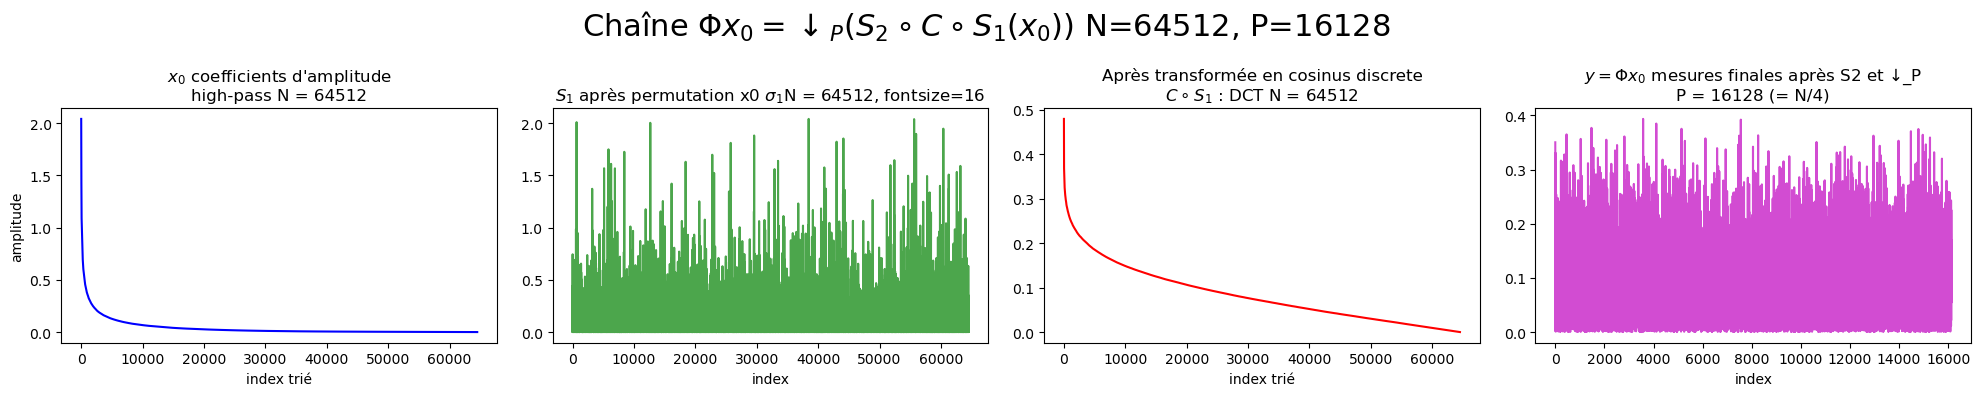

Nombre de coefficient haute fréquence : 64512
Nombre de mesures finales : 16128


In [15]:
# l'opérateur d'acquisition de mesures
y = Phi(x0,sigma1,sigma2,P)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# 1. x0 : coefficients high-pass originaux
axes[0].plot(np.sort(np.abs(x0))[::-1], 'b-')
axes[0].set_title(f'$x_0$ coefficients d\'amplitude\nhigh-pass N = {N}')
axes[0].set_xlabel('index trié')
axes[0].set_ylabel('amplitude')

# 2. Après S1 : permutation sigma1
S1_x0 = S(x0, sigma1)
axes[1].plot(np.abs(S1_x0), 'g-', alpha=0.7)
axes[1].set_title(f'$S_1$ après permutation x0 $\\sigma_1$N = {N}, fontsize=16')
axes[1].set_xlabel('index')

# 3. Après C∘S1 : DCT
CS1_x0 = C(S1_x0)
axes[2].plot(np.sort(np.abs(CS1_x0))[::-1], 'r-')
axes[2].set_title(f'Après transformée en cosinus discrete\n$C \\circ S_1$ : DCT N = {N}')
axes[2].set_xlabel('index trié')

# 4. y = Φx0 : mesures finales après S2 et ↓_P
axes[3].plot(np.abs(y), 'm-', alpha=0.7)
axes[3].set_title(f'$y = \\Phi x_0$ mesures finales après S2 et ↓_P\nP = {P} (= N/4)')
axes[3].set_xlabel('index')

plt.suptitle(f'Chaîne $\\Phi x_0 = \\downarrow_P(S_2 \\circ C \\circ S_1(x_0))$'f' N={N}, P={P}', fontsize=22)
plt.tight_layout()
plt.show()

print(f"Nombre de coefficient haute fréquence : {x0.shape[0]}")   # (N,)
print(f"Nombre de mesures finales : {y.shape[0]}")    # (P,)

#### `4.5.3. Résultat`

- `Figure 1:` Amplitudes triées est la plus importante en Compressed Sensing car elle montre visuellement que peu de coefficients haute-fréquence ont une grande amplitude (les premiers à gauche), la grande majorité des 61440 coefficients sont quasi nuls → Parcimonie confirmée : $x_0$ est bien sparse!

- `Figure 2:` Les coefficients sont mélangés aléatoirement par la permutation $\sigma_1$. L'amplitude totale est conservée (même norme), mais l'ordre est perdu. C'est une étape de scrambling pour que l'information soit répartie uniformément avant la DCT.

- `Figure 3:` DCT concentre l'énergie, quelques coefficients ont une grande amplitude (à gauche) et le reste est quasi nul. La DCT est une base adaptée qui compresse encore mieux l'information que la base ondelette originale. C'est ce qui rend les mesures très efficaces.

- `Figure 4:` Les P = N/4 => 15360 mesures finales. Chaque valeur est le produit scalaire entre $x_0$ et un atome aléatoire. L'amplitude est distribuée uniformément entre toutes les mesures grâce au mélange $S_2 \circ C \circ S_1$. On a réduit N=61440 → P=15360 coefficients tout en préservant l'information essentielle.



#### `4.5.4. L'opérateur adjoint`
_`Rappel :`_
- $x_0 = \{ \langle f, \psi_m \rangle \}_{m \in I_0}$ => coefficients d'ondelettes haute-fréquences
- $\Phi(x0)$ => l'opérateur Compress Sensing d'acquisition de mesures comprimées sur les hautes fréquences
_`L'opérateur adjoint est :`_ 
 - $ \Phi^* x = S_1^* \circ C^* \circ S_2^* (x) \circ \uparrow_P $ 
 - `où` $\uparrow_P$ `ajoute  N - P zéros à la fin d'un vecteur` 
 - $C^*$ est la transformée cosinus discrète inverse.
 - Attention se lit de gauche vers droite (application fonctionnelle) : $S_2^*(x)   →   C^*(S_2^*(x))   →   S_1^*(C^*(S_1^*(x)))→ [·]\uparrow_P$
 - Attention à la notation compacte (algèbre linéaire) :$\Phi^*  = S_1^* ∘  C^*  ∘  S_2^* ∘  \uparrow_P$

In [16]:
# Φ* : R^P → R^N
uparrow = lambda x,N,P: np.concatenate([x, np.zeros(N - P)])
# L'opérateur adjoint 
PhiS  = lambda x,N,P,sigma1S,sigma2S: Sinv_1(Cinv(Sinv_2(uparrow(x,N,P), sigma2S)),sigma1S)

Effectuer les mesures de compressed sensing Perform CS (sans bruitage).

- $\large x_0 = \{ \langle f, \psi_m \rangle \}_{m \in I_0}$ => coefficients d'ondelettes haute-fréquences
- $\Phi(x0)$ => l'opérateur Compress Sensing d'acquisition ou de mesures comprimées

In [17]:
# l'opérateur d'acquisition de mesures
y = Phi(x0,sigma1,sigma2,P)
print(f"P: {P}, phi.shape : {y.shape} N : {N}")
# L'opérateur adjoint 
z = PhiS(y,N,P,sigma1S,sigma2S)
print(f"n: {n}, phi.shape : {y.shape} phiS.shape : {z.shape}")

P: 16128, phi.shape : (16128,) N : 64512
n: 256, phi.shape : (16128,) phiS.shape : (64512,)


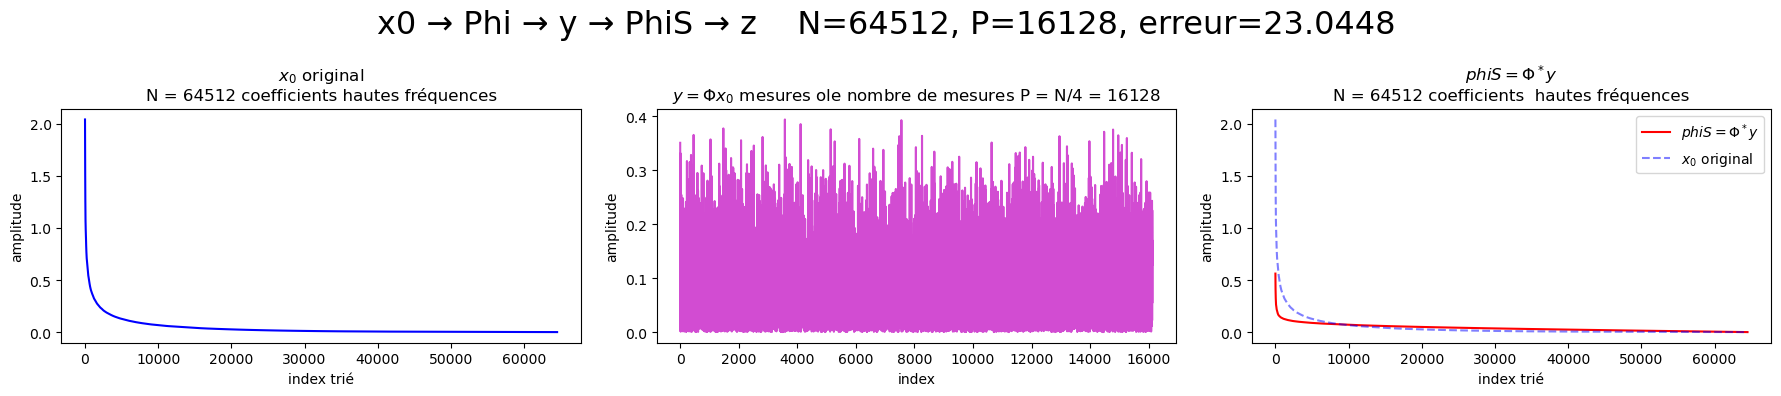

x0.shape          : (64512,)
y.shape           : (16128,)
z.shape           : (64512,)
||phiS - x0||     : 23.044759
||x0||            : 26.621626
erreur relative   : 0.865641


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. x0 original
axes[0].plot(np.sort(np.abs(x0))[::-1], 'b-')
axes[0].set_title(f'$x_0$ original\nN = {N} coefficients hautes fréquences')
axes[0].set_xlabel('index trié')
axes[0].set_ylabel('amplitude')

# 2. y = Φx0 : mesures
axes[1].plot(np.abs(y), 'm-', alpha=0.7)
axes[1].set_title(f'$y = \\Phi x_0$ mesures ole nombre de mesures P = N/4 = {P}')
axes[1].set_xlabel('index')
axes[1].set_ylabel('amplitude')

# 3. z = Φ*y : reconstruction
axes[2].plot(np.sort(np.abs(z))[::-1], 'r-', label='$phiS = \\Phi^* y$')
axes[2].plot(np.sort(np.abs(x0))[::-1], 'b--', alpha=0.5, label='$x_0$ original')
axes[2].set_title(f'$phiS = \\Phi^* y$\nN = {N} coefficients  hautes fréquences')
axes[2].set_xlabel('index trié')
axes[2].set_ylabel('amplitude')
axes[2].legend()

# ← suptitle simplifié sans \xrightarrow
erreur = np.linalg.norm(z - x0)
plt.suptitle(f'x0 → Phi → y → PhiS → z    N={N}, P={P}, erreur={erreur:.4f}', fontsize=23)
plt.tight_layout()
plt.show()

# Vérification numérique
print(f"x0.shape          : {x0.shape}")
print(f"y.shape           : {y.shape}")
print(f"z.shape           : {z.shape}")
print(f"||phiS - x0||     : {np.linalg.norm(z - x0):.6f}")
print(f"||x0||            : {np.linalg.norm(x0):.6f}")
print(f"erreur relative   : {np.linalg.norm(z - x0) / np.linalg.norm(x0):.6f}")

- erreur relative ≈ 87% d'erreur, c'est le comportement attendu de $\Phi^∗$
- $\Phi^*$ agit comme un filtre passe-bas, il lisse et atténue $x0$
- La vraie reconstruction de $x0$ se fait via l'algorithme itératif (ISTA, FISTA...) $\min_x=\frac{1}{2}||\Phi x − y||^2+λG(x)$

## `5. Pseudo inverse de Moore-Penrose`
__La propriété fondamentale de la pseudo-inverse Moore-Penrose est :__ 
- $\Phi^+=(\Phi^∗\Phi)^{−1}\Phi^∗$
__On considère un opérateur de compressed sensing :__ 
- $\Phi = \downarrow_P \circ \underbrace{\left(S_2 \circ C \circ S_1\right)}_{\text{orthogonal } U}=\downarrow_P \circ U$
__Pourquoi__ $\Phi^+ = \Phi^*$: 
 - $\Phi = \downarrow_P \circ S_2 \circ C \circ S_1$
 - $\Phi^∗=S_1^∗ \circ C^∗ \circ S_2^* \circ \uparrow_P$
 - $\Phi\Phi^∗= \downarrow_P \circ ( S_2 \circ C \circ S_1) \circ (S_1^∗ \circ C^∗ \circ S_2^∗ ) \circ \uparrow_P$
 - $\Phi\Phi^∗ = \downarrow_P \circ \underbrace{S_2 \circ C \circ S_1 \circ S_1^∗ \circ C^∗ \circ S_2^∗}_{=I}\circ\uparrow_P$ = $\downarrow_P \circ \uparrow_P=I_p$
__Calcul de__ $\Phi \Phi^*$ 
- on a : $\Phi \Phi^*= (\downarrow_P \circ U) \circ (U^* \circ \downarrow_P^*)= \downarrow_P \circ U U^* \circ \downarrow_P^*.$
 - comme $U$ est orthogonal ($U^* U = I$) : $\Phi \Phi^*= \downarrow_P \circ I \circ \downarrow_P^* = \downarrow_P \circ \downarrow_P^*$
__Donc__ : $ ΦΦ^∗ = I_P ⇒ Φ^+ = Φ^∗$ 

### `5.1. Exercice 2`
- L'égalité $\Phi^+ y =\Phi^* y$ repose sur la notion de pseudo-inverse de Moore-Penrose permettant la  reconstruction d'une image. 
- Pour une matrice $\Phi \in \mathbb{R}^{P \times N}$, la pseudo-inverse $\Phi^+$ définie la solution du problème $min_x ||x||_2$ sous contrainte $\Phi_x=y$
- L'égalité $\Phi^+ = \Phi^*$ est valable car $\Phi$ est construit à partir d'opérations orthogonales (permutations + DCT orthogonale),

x_rec.shape : (64512,)
coeffs_arr : (256, 256), fw_rec_2d : (256, 256)
fw_rec : (65536,), coeffs_slices : 4


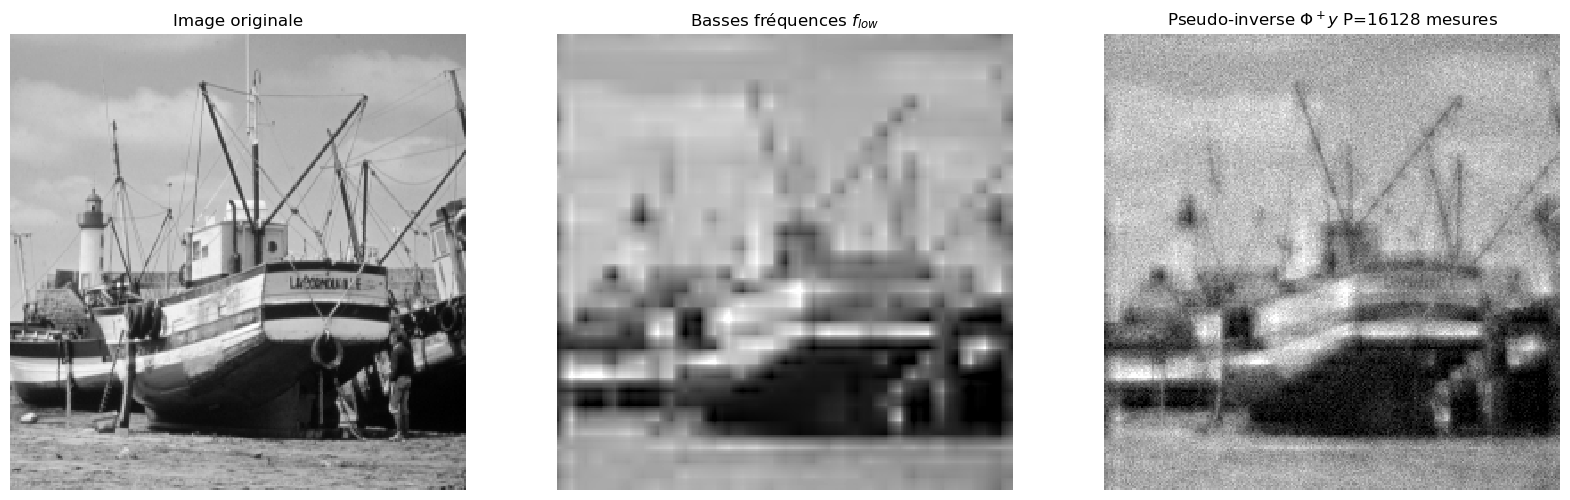

In [19]:
# l'opérateur d'acquisition de mesures
y = Phi(x0,sigma1,sigma2,P) # retourne un vecteur de mesures de dimension P 
# L'opérateur adjoint renvoie un vecteur dans l’espace des coefficients (dimension N),
x_rec = PhiS(y,N,P,sigma1S,sigma2S)
print(f"x_rec.shape : {x_rec.shape}")  # (N,)

# mise à zéro de tous les coéfficient basses fréquences
A = np.ones((coeffs_arr.shape))  
A[0:coeffs_slices[0][0].stop, 0:coeffs_slices[0][1].stop] = 0

# retourne les indices de la matrice ou se trouvent les coefficients hautes fréquences
I0 = np.where(A.flatten()==1)[0]

# 3. Reconstruire l'image complète en appliquant les coeffcient issus de la pseudo-inverse
fw_rec = coeffs_arr.flatten().copy()
fw_rec[I0] = x_rec                   # replacer les coefficients high-pass

fw_rec_2d = fw_rec.reshape(coeffs_arr.shape)

print(f"coeffs_arr : {coeffs_arr.shape}, fw_rec_2d : {fw_rec_2d.shape}")
print(f"fw_rec : {fw_rec.shape}, coeffs_slices : {len(coeffs_slices)}") 

# Reconstruire depuis les coefficients d'ondelettes
coeffs_rec = pywt.array_to_coeffs(fw_rec_2d, coeffs_slices, output_format='wavedec2')
f_rec = pywt.waverec2(coeffs_rec, wavelet='db2', mode='periodization')

# 4. Affichage
plt.figure(figsize=(20, 15))
imageplot(clamp(f0),    'Image originale',                            [1, 3, 1])
imageplot(clamp(f_low), r'Basses fréquences $f_{low}$',               [1, 3, 2])
imageplot(clamp(f_rec), f'Pseudo-inverse $\Phi^+ y$ P={P} mesures',   [1, 3, 3])
plt.show()

#### `5.1.1 Résultat`

- `Figure 1 : Image nette,` avec tous les détails contours nets, textures visibles
- `Figure 2 : Image floue,` contours lissés, détails perdus, seule l'enveloppe générale est visible
- `Figure 3 : Image bruitée,` structure reconnaissable mais granuleuse, contours visibles mais bruités

`Interprétation :` 
- Reconstruction par pseudo-inverse $\Phi^+ y = \Phi^* y$ avec P = 3840 mesures, 25% des N = 15360 coefficient HF. 
- La structure du bateau est reconnaissable, ce qui montre que l'information essentielle a été capturée. 
- Mais il y a du bruit car la pseudo-inverse $\Phi^*$ est une reconstruction naïve qui ne tient pas compte de la parcimonie de $x_0$.


## `6. Reconstruction CS, algorithme Douglas-Rachford`
### `6.1 Principe`
Ce problème favorise les solutions parcimonieuses grâce à la norme $\ell^1$, qui permet de retrouver $x_0$ avec moins de mesures que de coefficients.
`À partir des mesures parcimonieuses hautes fréquences`_ 
- $ y = \Phi x_0$ reconstruire le signal origine $x_0\in\mathbb{R}^N$ en résolvant le problème de minimisation 
   - $x_0$ les coefficients hautes fréquences,
   - $\Phi$ opérateur d'extration de mesures (Compress Sensing)
   - $y$ mesures parcimonieuses (matrice x vecteur)
- $min_{x \in \mathbb{R}^N}||x||_1$ sous contrainte $\Phi x = y$ où $\Phi \in \mathbb{R}^{P \times N}$ avec $P \ll N$, 

  - N = le nombre de pixels dans l'image
  - P = N // 4 nombre de mesures requis par les contraintes Shanon-Nyquist 
#### _`6.1.1. Décomposition du problème`_
Le problème de la forme $\min_x F(x) + G(x)$ est alors $\min_x \iota_{\mathcal{C}}(x) + ||x||_1$
- $F(x) = \iota_{\mathcal{C}}(x)$ où $\mathcal{C} = \{x \mid \Phi x = y\}$ est l’ensemble des vecteurs compatibles avec les mesures.
   - $\begin{cases}  F(x) = 0 \text{ si } \Phi x = y \\ F(x)=+\infty \text{ sinon } \end{cases}$

- $G(x) = ||x||_1$ => pénalise la norme $\ell1$ et favorise la parcimonie => $G(x) = ||x||_1 = \sum|x_i|$
  - $G(x)=\lambda||x||_1$ (sparsité $\ell1$ sur les Hautes Fréquences).
#### _`6.1.2. Schéma standard de Douglas-Rachford`_
L'algorithme itère les deux opérateurs proximaux dans l'ordre inverse :

$ \begin{cases} x_{k+1} = \text{prox}_{\gamma G}(z_k) \\ z_{k+1} = z_k + \mu(\text{prox}_{\gamma F}(2x_{k+1}-z_k) - x_{k+1}) \end{cases}$
 où :
- $\text{prox}_{\gamma G}$ seuillage doux 
  - $\text{prox}_{\gamma G}(x)_i = \text{sign}(x_i) \cdot \max(|x_i| - \gamma, 0)$
- $\text{prox}_{\gamma F}$ projection sur $\mathcal{C}$
  - $\text{prox}_{\gamma F}(x) = x + \Phi^*(y - \Phi x)$
    - $\gamma > 0$ pas de régularisation
    - $\mu \in (0, 2)$ paramètre de relaxation

### `6.2. Exercice 3:` 
 - Implémenter les opérateurs proximal et proximal réfléchi de $F$ et $G$.
- Retrouver $x$ à partir de $y = \Phi x_0$ avec  P = N/4, c.a.d. 25% des coefficients de $x_0$.
  - _`on connaît y et x0`_
  - _`retrouver x à partir de y et x0`_
__Problème initial :__

In [20]:
print("len(x0), le nombre de coefficients ondelettes haute fréquence de l'image N =",len(x0))
print("len(x0)/4 :",len(x0)/4," nombre de mesures y.shape :",y.shape)

len(x0), le nombre de coefficients ondelettes haute fréquence de l'image N = 64512
len(x0)/4 : 16128.0  nombre de mesures y.shape : (16128,)



__Comment on vérifie ?__
Dans le contexte du TP (exceptionnelle) on connaît $x_0$ donc on peut comparer la reconstruction avec l'original.  
   - $\text{prox}_{\gamma G}$ seuillage doux => $\text{prox}_{\gamma G}(x)_i = \text{sign}(x_i) \cdot \max(|x_i| - \gamma, 0)$
   - $\text{prox}_{\gamma F}$ projection sur $\mathcal{C}$ => $\text{prox}_{\gamma F}(x) = x + \Phi^*(y - \Phi x)$

In [21]:
# Opérateurs proximaux
prox_G = lambda x,gamma: np.sign(x) * np.maximum(np.abs(x) - gamma, 0)  # seuillage doux
prox_F = lambda x,y,sigma1,sigma2,P,N,sigma1S,sigma2S: x + PhiS(y-Phi(x,sigma1,sigma2,P),N,P,sigma1S,sigma2S)

### `6.3 Exercice 4`
Implémenter l'algorithme Douglas-Rachford. Conserver l'évolution des traces $\ell^1$ norm $G(x_k)$.

__`Rappel : Schéma de Douglas-Rachford`__
L'algorithme itère les deux opérateurs proximaux dans l'ordre inverse :

$ \begin{cases} x_{k+1} = \text{prox}_{\gamma G}(z_k) \\ z_{k+1} = z_k + \mu(\text{prox}_{\gamma F}(2x_{k+1}-z_k) - x_{k+1}) \end{cases}$
 - où :
   - $\text{prox}_{\gamma G}$ seuillage doux => $\text{prox}_{\gamma G}(x)_i = \text{sign}(x_i) \cdot \max(|x_i| - \gamma, 0)$
   - $\text{prox}_{\gamma F}$ projection sur $\mathcal{C}$ => $\text{prox}_{\gamma F}(x) = x + \Phi^*(y - \Phi x)$
   
     - $\gamma > 0$ pas de régularisation
     - $\mu \in (0, 2)$ paramètre de relaxation

In [22]:
# Stocker la norme L1 à CHAQUE itération
L1_history = []  # liste vide pour stocker les valeurs
residu_history  = []
N = len(x0)
niter=30000
gamma = .05
mu = 1.98
# ✅ 
z = np.zeros(N)
x_tmp = np.zeros(N)
for k in range(niter):
    x = prox_G(z,gamma)
    z = z + mu * (prox_F((2*x - z),y,sigma1,sigma2,P,N,sigma1S, sigma2S) - x)
    x_tmp = x.copy()
    if k % 300 == 0:
       residu_history.append(np.linalg.norm(Phi(x, sigma1, sigma2, P) - y))
       L1_history.append(np.sum(np.abs(x_tmp)))   # ← stocker G(x_k) = ||x||₁
x_CS = x_tmp.copy()       

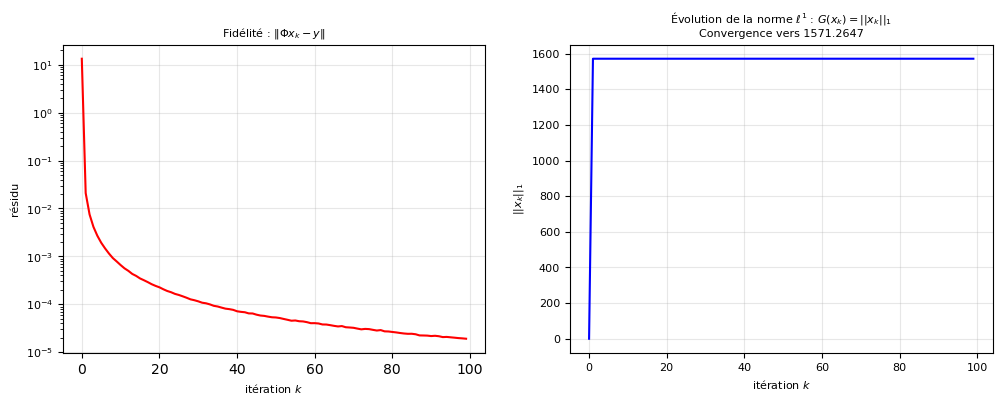

In [23]:
# ── Tracé ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Fidélité aux mesures
axes[0].plot(residu_history, 'r-', linewidth=1.5)
axes[0].set_title(r'Fidélité : $\|\Phi x_k - y\|$', fontsize=8)
axes[0].set_xlabel('itération $k$', fontsize=8)
axes[0].set_ylabel('résidu', fontsize=8)
axes[1].tick_params(axis='x', labelsize=8)  # abscisse
axes[0].tick_params(axis='y', labelsize=8)  # ordonnée
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Parcimonie
axes[1].plot(L1_history, 'b-', linewidth=1.5)
axes[1].set_title(f'Évolution de la norme $\\ell^1$ : $G(x_k) = ||x_k||_1$\n' f'Convergence vers {L1_history[-1]:.4f}', fontsize=8)
axes[1].set_xlabel('itération $k$', fontsize=8)
axes[1].set_ylabel(r'$||x_k||_1$', fontsize=8)
axes[1].tick_params(axis='x', labelsize=8)  # abscisse
axes[1].tick_params(axis='y', labelsize=8)  # ordonnée
axes[1].grid(True, alpha=0.3)

#### `6.3.1. Résultat`

« La norme $\ell1$ de la solution augmente d’abord rapidement, le schéma activant des coefficients pour satisfaire les contraintes de mesure, puis se stabilise autour de 1561. 

Cette forme montée‑puis‑plateau est typique d’une convergence de Douglas–Rachford vers une solution parcimonieuse. »

`Fidélité des mesures :` 
- Le résidu décroît de manière monotone et rapide en échelle logarithmique, de ~10¹ à ~10⁻⁶. 
- Cela confirme que l'algorithme converge vers une solution qui respecte parfaitement les mesures ($\Phi x \approx y$).

`Parcimonie : ` 
- La norme $\ell^1$ converge rapidement vers ~1000, mais ne coïncide pas avec $||x_0||_1 = 1521$. 
- Cela suggère que Douglas-Rachford trouve une solution plus parcimonieuse que $x_0$ elle-même.





In [24]:
# Comparaison avec la pseudo-inverse
x_rec = PhiS(y,N,P,sigma1S,sigma2S)
# Comparaison
print("Comparaison Douglas-Rachford vs Pseudo-inverse")
print(f"Erreur Douglas Rachford ||x_DR  - x0|| = {np.linalg.norm(x_tmp - x0):.6f}") # Douglas-Rachford
print(f"Erreur Pseudo inverse   ||x_rec - x0|| = {np.linalg.norm(x_rec - x0):.6f}") # Pseudo-inverse
print(f"Gain Pseudo-inverse / Douglas Rachford = {np.linalg.norm(x_rec - x0)/np.linalg.norm(x_tmp-x0):.2f} signifie que Douglas Rachford est meilleur")

# Normalisé par ||x0||
print(f"Erreur relative Douglas-Rachford = {np.linalg.norm(x_tmp - x0)/np.linalg.norm(x0):.4f}")
print(f"n: {n}, Erreur relative Pseudo-inverse Moore-Penrose => Φ* = {np.linalg.norm(x_rec - x0)/np.linalg.norm(x0):.4f}")

Comparaison Douglas-Rachford vs Pseudo-inverse
Erreur Douglas Rachford ||x_DR  - x0|| = 16.137490
Erreur Pseudo inverse   ||x_rec - x0|| = 23.044759
Gain Pseudo-inverse / Douglas Rachford = 1.43 signifie que Douglas Rachford est meilleur
Erreur relative Douglas-Rachford = 0.6062
n: 256, Erreur relative Pseudo-inverse Moore-Penrose => Φ* = 0.8656


#### `6.3.2. Exercice 5`
Afficher l'image reconstruite à partir des P0 mesures et des P mesures CS.
- Mesures basse fréquence :  $P0 = (n/2^{k0})^2$  (coefficient LL de l'image ondelette)
- Mesures haute fréquence :  $P  = N/4$         (mesures CS via Douglas-Rachford)
Le nombre total de mesures utilisées  :  $P+P0$

Il reste à vérifier si l’image reconstruite correspondante (LL + HF_CS), l’erreur $||f_{combined} −f0||$ ou le PSNR, pour vérifier que cette solution « stable » est aussi visuellement satisfaisante.

In [25]:
fw_rec = coeffs_arr.flatten().copy()   # contient LL + HF originaux
fw_rec[I0] = z                         # tu remplaces tous les HF par z
fw_rec_2d = fw_rec.reshape(coeffs_arr.shape)
coeffs_rec = pywt.array_to_coeffs(fw_rec_2d, coeffs_slices, output_format='wavedec2')
f_rec = pywt.waverec2(coeffs_rec, wavelet='db2', mode='periodization')

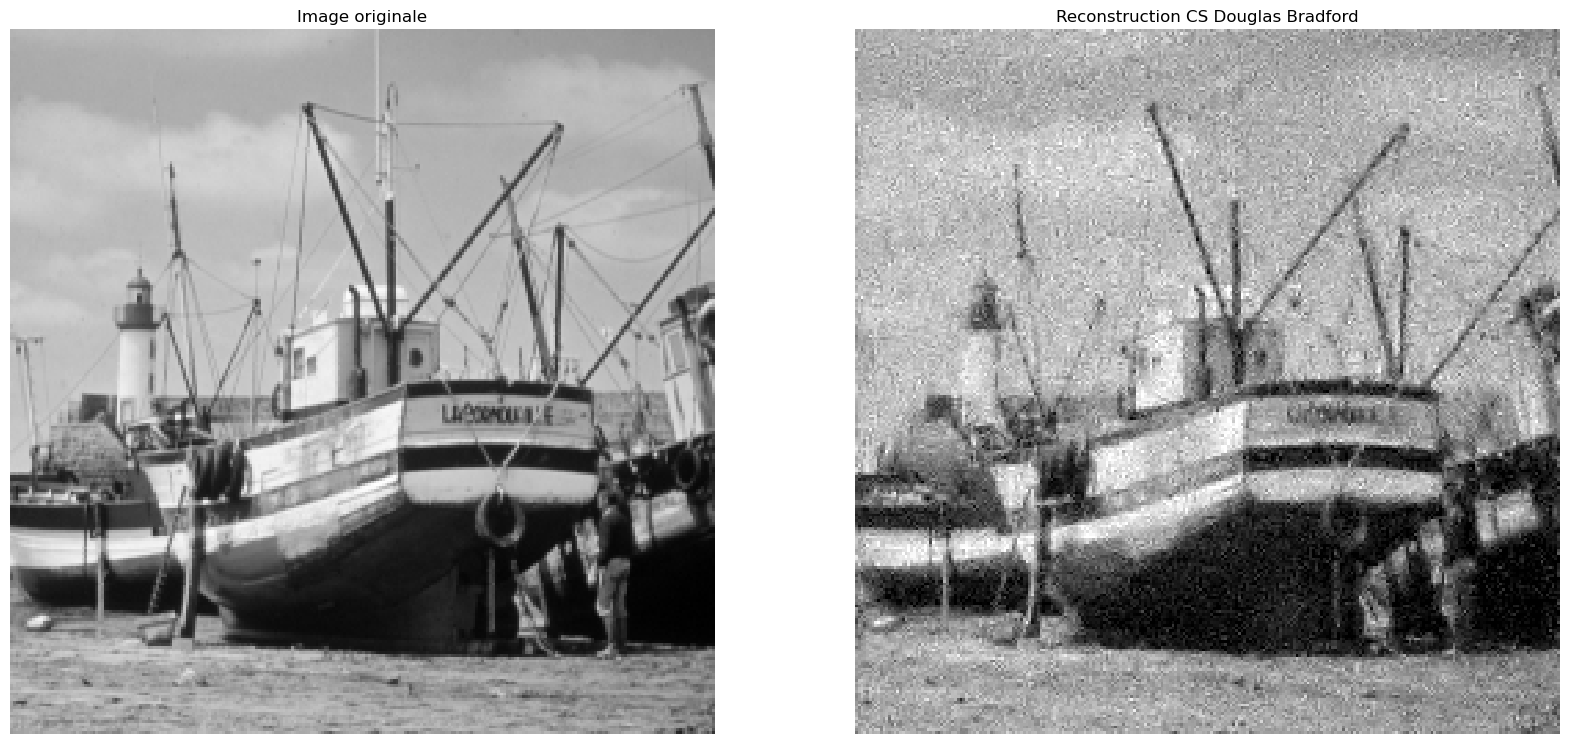

In [26]:
# 4. Affichage
plt.figure(figsize=(20, 15))
imageplot(clamp(f0),    'Image originale',                        [1, 2, 1])
imageplot(clamp(f_rec), f'Reconstruction CS Douglas Bradford',   [1, 2, 2])
plt.show()

#### `6.3.3. Résultat`

Le fait que l’image de droite soit ultra bruitée signifie pas que la recomposition est fausse, mais que le vecteur $z$ produit par Douglas–Rachford ne ressemble pas à des coefficients d’ondelettes « réalistes » pour cette image. 
 - il contient beaucoup d’énergie haute fréquence non structurée (comme un bruit), et 
 - quand on injecte ce $z$ dans les HF, on ajoute du bruit sur toute l’image, par‑dessus les LL d’origine.

La chaîne « LL d’origine + HF_CS → waverec2 » est correcte
 - la reconstruction CS via le modèle $min||x||_1 $, $Φx=y$ 
 - avec cette opérateur $Φ$ ne donne pas de bons coefficients hautes fréuences.

Comparaison, 
 - DR converge numériquement (norme $\ell1$ se stabilise),
 - sur cet opérateur d’acquisition, la solution parcimonieuse trouvée dans l’espace des HF 
 - ne correspond pas à des détails d’image pertinents, ce qui produit une reconstruction très bruitée,
 - l’approche « P0 + P » est plus convaincante quand on reconstruit dans la base ondelette complète 
 - avec ISTA/FISTA, plutôt que sur les seuls HF avec ce modèle CS.

In [27]:
# 3.2 Coefficients combinés : LL d'origine + HF reconstruits
fw_combined = coeffs_arr.flatten().copy()  # contient LL + HF originaux
fw_combined[I0] = x_CS                     # remplace à partir des indice IO, les valeurs HF par CS
fw_combined_2d = fw_combined.reshape(coeffs_arr.shape)
# 4. Reconstruction image complète
coeffs_combined = pywt.array_to_coeffs(fw_combined_2d, coeffs_slices, output_format='wavedec2')
f_combined = pywt.waverec2(coeffs_combined, wavelet='db2', mode='periodization')

# 5. Comparer avec la reconstruction CS seule (sans P0)
fw_HFCSBR_only = np.zeros_like(coeffs_arr).flatten() 
fw_HFCSBR_only[I0] = x_CS
fw_HFCSBR_only_2d = fw_HFCSBR_only.reshape(coeffs_arr.shape)
coeffs_CS_only = pywt.array_to_coeffs(fw_HFCSBR_only_2d, coeffs_slices, output_format='wavedec2')
f_CSHFBR_only = pywt.waverec2(coeffs_CS_only, wavelet='db2', mode='periodization')

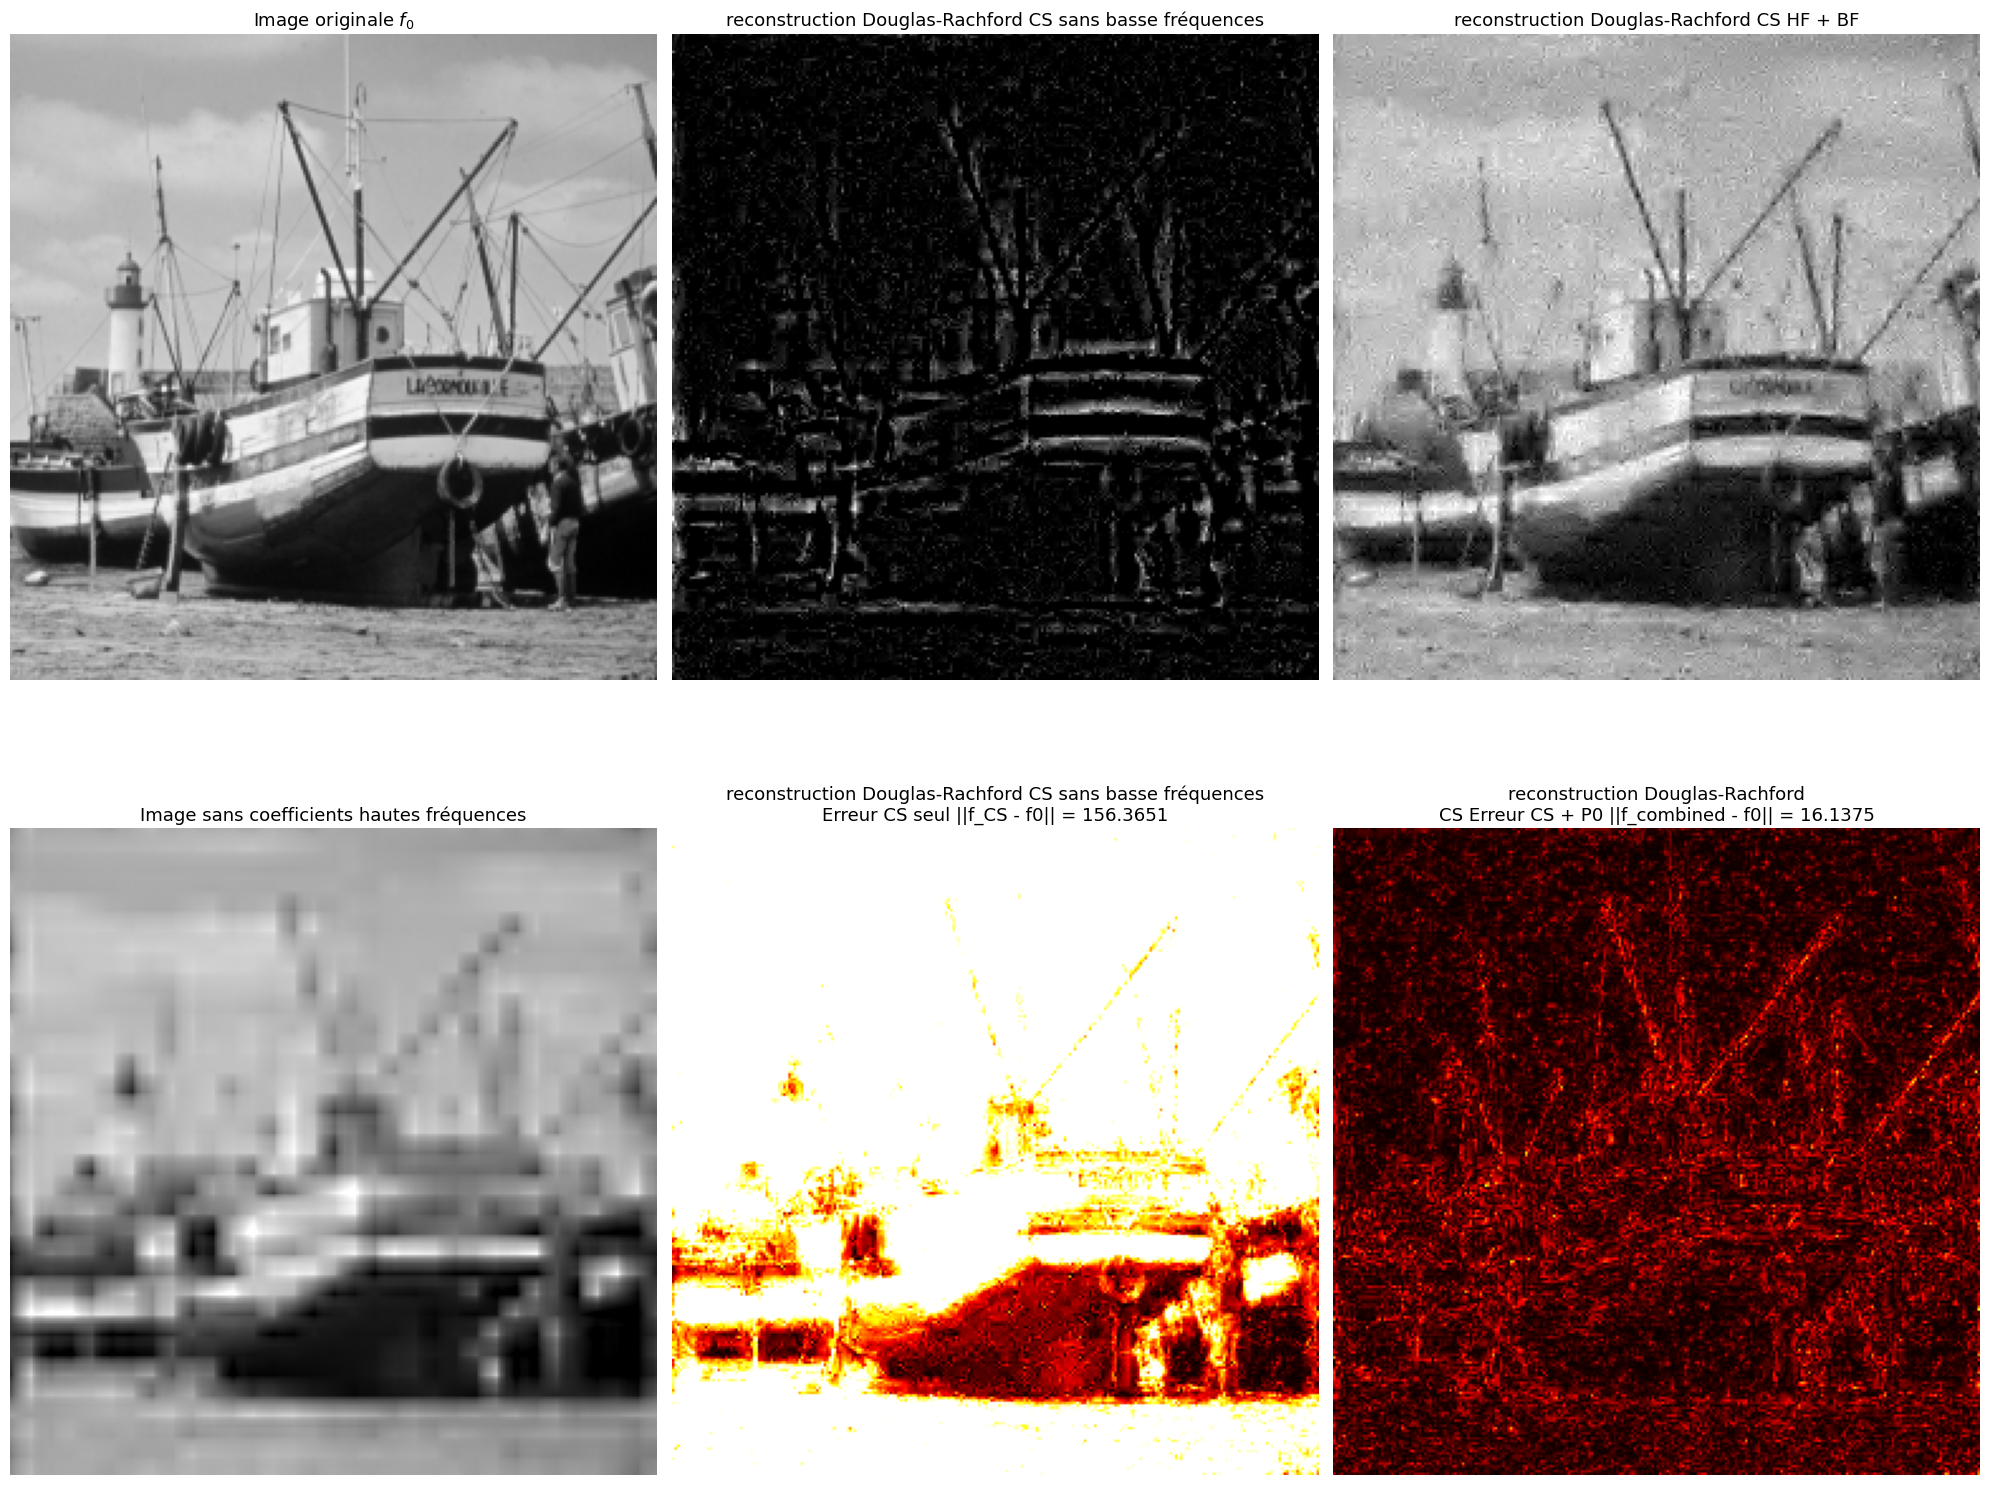


=== Comparaison quantitative ===
PSNR f_CS_only  : -92.05 dB
PSNR f_combined : -72.32 dB
PSNR f_low      : -76.67 dB

||f_CS_only - f0||   : 156.3651
||f_combined - f0||  : 16.1375
n: 256, ||f_low - f0||       : 26.6216


In [28]:

# =================================================================
# Affichage
# =================================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 17))

# Rangée 1 : Image reconstruite
axes[0, 0].imshow(clamp(f0), cmap='gray')
axes[0, 0].set_title(f'Image originale $f_0$', fontsize=13)
axes[0, 0].axis('off')

axes[0, 1].imshow(clamp(f_CSHFBR_only), cmap='gray')
axes[0, 1].set_title(f'reconstruction Douglas-Rachford CS sans basse fréquences', fontsize=13)
axes[0, 1].axis('off')

axes[0, 2].imshow(clamp(f_combined), cmap='gray')
axes[0, 2].set_title(f'reconstruction Douglas-Rachford CS HF + BF', fontsize=13)
axes[0, 2].axis('off')

# Rangée 2 : Erreurs
err_CS_only = np.abs(f_CSHFBR_only - f0)
err_combined = np.abs(f_combined - f0)

im1 = axes[1, 0].imshow(clamp(f_low), cmap='gray')
axes[1, 0].set_title(f'Image sans coefficients hautes fréquences', fontsize=13)
axes[1, 0].axis('off')

im2 = axes[1, 1].imshow(err_CS_only, cmap='hot', vmin=0, vmax=0.5)
axes[1, 1].set_title(f'reconstruction Douglas-Rachford CS sans basse fréquences\nErreur CS seul ||f_CS - f0|| = {np.linalg.norm(f_CSHFBR_only-f0):.4f}', fontsize=13)
axes[1, 1].axis('off')

im3 = axes[1, 2].imshow(err_combined, cmap='hot', vmin=0, vmax=0.5)
axes[1, 2].set_title(f'reconstruction Douglas-Rachford\nCS Erreur CS + P0 ||f_combined - f0|| = {np.linalg.norm(f_combined-f0):.4f}', fontsize=13)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# =================================================================
# Comparaison quantitative
# =================================================================
print(f"\n=== Comparaison quantitative ===")
print(f"PSNR f_CS_only  : {20*np.log10(1/np.linalg.norm(f_CSHFBR_only-f0)/np.sqrt(f0.size)):.2f} dB")
print(f"PSNR f_combined : {20*np.log10(1/np.linalg.norm(f_combined-f0)/np.sqrt(f0.size)):.2f} dB")
print(f"PSNR f_low      : {20*np.log10(1/np.linalg.norm(f_low-f0)/np.sqrt(f0.size)):.2f} dB")
print(f"\n||f_CS_only - f0||   : {np.linalg.norm(f_CSHFBR_only-f0):.4f}")
print(f"||f_combined - f0||  : {np.linalg.norm(f_combined-f0):.4f}")
print(f"n: {n}, ||f_low - f0||       : {np.linalg.norm(f_low-f0):.4f}")

### `Synthèse`
- Les coefficients basse fréquence (P0) sont indispensables pour la structure globale et une bonne approximation de l’image.  
- Les coefficients haute fréquence, reconstruits par CS via Douglas–Rachford, apportent des détails mais aussi beaucoup de bruit dans cette configuration.  
- La combinaison P0 + P donne une image acceptable mais bruitée, tandis que **P seul** (CS sur HF uniquement) ne suffit pas du tout.

__`On peut en conclure :`__
- que l’algorithme Douglas–Rachford sur les hautes fréquences converge numériquement (norme $\ell1$ stabilisée),  
- avec l’opérateur $\Phi$, la solution parcimonieuse retrouvée reste très bruitée,  
- c'est la présence des LL exacts (P0) qui sauve la qualité perceptuelle de la reconstruction.


## `7. Reconstruction CS avec Parcimonie par Blocs`
### `7.1. Principe :` 
__Qu'est-ce que la reconstruction avec parcimonie par bloc.__ 
- Afin d'améliorer la reconstruction CS avec parcimonie $\large \ell_1$ on passe parcimonie structurée par blocs consistant à  : 
- regrouper la position des coefficients en blocs de $w^2$ pixels, par la découpe des indices {1,…,N} en blocs disjoints $B_k$, 
- puis à pénaliser la somme des normes $\ell_2$ de ces groupes par :  
  - $G(x)=\sum_k ||x_{B_k}||_2$
    - si x est un vecteur de l’image, un indice correspond à la position d’un pixel.
    - un indice $i$ désigne la position d’un coefficient dans le vecteur $x\in \mathbb{R}^N$ 
    - $(B_{k})_k$ est une partition (segmentation disjointe) de l'ensemble d'indices ${1,…,N}$ 
    - $x_{B_k}=\{x_i\}_{i \in B_k} \in \mathbb{R}^{∣B_k∣}$ contient les coefficients appartenant au bloc $k$, 
    - $\large \ell_{2,1}$ est la norme, $\ell_{2}$ à l’intérieur de chaque bloc, puis on effectue la somme (norme $\ell_{1}$) des normes $\ell_2$  de tous les blocs. 
$$||x||_{2,1} = \sum_k||xB_k||_2$$
### _`7.2. L'opérateur proximal bloc`_
 - $\forall k,\quad \operatorname{Prox}_{\gamma G}(x)_{B_k}=\begin{cases}\left(1 - \dfrac{\gamma}{\|x_{B_k}\|_2}\right) x_{B_k} & \text{si } \|x_{B_k}\|_2 > \gamma,\\ 0 & \text{sinon.} \end{cases}$

Et la version coordonnée :
- $ \forall k, \forall m \in B_k ,\quad \text{(Prox}_{\gamma G}(x))_m = \max(0, 1−\large \frac{\gamma}{||xB_k||_2} )x_m$

### _`7.3. Partie ISTA/FISTA`_ 
ISTA/FISTA, méthode d’optimisation proximale de premier ordre capable de résoudre des problèmes du type :  
- $min_x F(x)=f(x)+g(x)$, où 

  - f la partie **lisse** différentiable partout avec un gradient $∇f$ Lipschitz gradient et 
  - g la partie **non lisse** possiblement non différentiable et convexe 
    - pénalisation lasso $\ell_1$, fonction indicatrice d’un ensemble, norme $\ell_{2,1}$ , TV, etc.  

`Un algorithme proximal type ISTA/FISTA fait, à chaque itération k.`
#### `7.3.1 Pas de gradient sur le terme de données :` 
- $f(x)= \frac{1}{2}||\Phi x−y||_2^2 , \qquad \nabla f(x) = \Phi^*(\Phi x - y) $, 
mise à jour intermédiaire avec un pas de $\gamma$ : 
 - $x^{k+\frac{1}{2}} = x^k - \gamma \nabla f(x^k)$

   - $\Phi x$ = opérateur direct (par exemple $A\Phi^{−1}x$).
   - $f(x)= \frac{1}{2}||\Phi x−y||_2^2$  = terme de données.
#### `7.3.2 Pas de proximal bloc sur G:`
- $x^{k+1} =\text{Prox}_{γλG}(x^{k+\frac{1}{2}})$
_Il s'écrit sous la forme :_
- $\forall m \in B_i \text{ , Prox}_{γG}(x)_i = \max(0,1 − \frac{γ}{||x_{B_i}||})x_i$ 
    -  $w × w$ : blocs uniformes pixels. 
    - $B_i ⊂ \{1,…,N\}$ l’ensemble des indices du bloc numéro i.
    - $m \in B_i$ un indice, il désigne un coefficient de ce bloc (un pixel du vecteur x)
- c’est l'opérateur de seuillage doux : 
   - si la norme du bloc est petite, on met tout le bloc à 0, 
   - sinon on contracte tout le bloc d'un facteur $1−\frac{γ}{||x_{B_i}||_2}$  


`C'est la préparation du seuillage par blocs :` 
- on sait quels coefficients CS appartiennent à chaque bloc.  
- ce qui permettra d'appliquer l'opérateur proximal $\text{Prox}_{γG}$ bloc par bloc.

Pour $w = 4$, chaque bloc est un carré de 16 pixels :
- Le seuillage proximal par bloc calcule : $\text{Prox}_{γG}(x)_i=max(0,1−\large \frac{γ}{||x_{B_i}||})x_i$
  - on a besoin de tous les $w^2$ coefficients du bloc pour calculer $||x_{B_i}||$. 
  - si un pixel manque → le bloc est inutilisable → on le rejette.
### `7.4 Exercice 6:` 
__Recoder l’image:__
 - $q^2$ représente une grande liste de blocs, 
 - chaque bloc décrit par $w^2$ indices de lignes/colonnes. 
 Cette structure sert à exprimer la pénalisation en parcimonie par blocs (norme $\ell_{2,1})$:
 - construire un opérateur de reconstruction bloc‑par‑bloc (prox, mise à jour, etc.), 
 - __`utiliser les mesures IRM pour contraindre certains pixels à rester égaux aux données mesurées`__.  

_`Retirer le bloc qui sort de l'image`_  
- Tous les blocs $w×w$ - ⬇️
- blocs débordant hors image - ⬇️ (filtre précédent sur $X+dX > n$)    
- blocs avec pixels non mesurés - ⬇️ (ce filtre)
- Blocs valides et complets → prêts pour le seuillage proximal par blocs

`Afficher la structure en blocs dans l’espace des coefficients`
- pour afficher la structure, une image fictive suffit, et la façon dont les indices sont construits.
  - une image de taille n×n (ou bien un tableau numpy génèré),
  - la liste des pixels observés IRM, donc rows_IRM, cols_IRM,
  - la carte qui code les indices de mesures (1..N) sur l’image,
  - la décomposition en blocs via X, Y, dX, dY,
  - le filtrage, des indices de mesures par bloc.
- pour vérifier la structure des blocs dans l’espace des coefficients : 
  - à qui appartient à quel bloc, 
  - quels indices sont groupés, 
- pour tester le code de prox on peut travailler avec un vecteur de mesures fictif $y$, 
- la structure des blocs ne dépend pas du contenu de $y$, seulement de la géométrie des indices.
- Les mesures CS “réelles” interviennent lorsque l'on lie cette structure à l’équation $y=Ax$

In [29]:
import numpy as np

# 1. Paramètres globaux
n = f0.shape[0]          # image n x n
w = 2                   # taille des blocs w x w
N = f0.size
m = 2*(n**2) // 3          # 75 % de pixels mesurés
print("f0.shape : ",f0.shape,"n : ",n)
# 2. IRM Indices des pixels Réellement Mesurés (0-base)
IRM = np.random.choice(n*n, m, replace=False)
rows_IRM = IRM // n # indices de ligne
cols_IRM = IRM %  n # indices de colonne

# 3. Masque image de mesure M_img (bool)
M_img = np.zeros((n, n), dtype=bool)
M_img[rows_IRM, cols_IRM] = True   # indice des pixels mesurés en ligne et colonne = True sinon False 
print("M_img.shape : ",M_img.shape,"n : ",n)
# 4. Grille de blocs réguliers (1-base)
v  = np.arange(1, n+1, w)        # liste tous les coins supérieurs-gauches de chacun des blocs
dv = np.arange(0, w)             # liste les pixel de décalages internes par bloc
print("v.shape :", v.shape, "dv.shape :", dv.shape)

dX, dY, X, Y = np.meshgrid(dv, dv, v, v, indexing='ij')
print("X.shape :", X.shape, "dX.shape :", dX.shape)

q = X.shape[2]                   # nombre de blocs par dimension = n // w

# 5. Passage en liste de blocs (w^2, q^2)
X  = X.reshape(w*w, q*q)
Y  = Y.reshape(w*w, q*q)
dX = dX.reshape(w*w, q*q)
dY = dY.reshape(w*w, q*q)

print("X.reshape : ", X.shape, "X.shape[2] = q :", q, "  q*q :", q*q)

# 6. Filtrage géométrique : blocs entièrement dans l'image
# (ici, tous les blocs réguliers sont dans l'image si n est multiple de w,
# mais on garde ce test pour généraliser
hors_image = (X + dX > n) | (Y + dY > n)   # 1-base
blocs_hors = (hors_image.sum(axis=0) > 0) # si >0 => au moins un pixel hors de l'image

valide_geo = ~blocs_hors
print("nb blocs valides géométriquement :", valide_geo.sum())

X  = X[:, valide_geo]
Y  = Y[:, valide_geo]
dX = dX[:, valide_geo]
dY = dY[:, valide_geo]

# 7. Indices 0-base des pixels des blocs valides
row = (X + dX - 1).astype(int)   # 0..n-1
col = (Y + dY - 1).astype(int)

print("nb de row valides row.shape : ", row.shape)  # (w*w, nb_blocs_valides)
print("nb de col calides col.shape : ", col.shape)  # (w*w, nb_blocs_valides)

# 8. Masque de mesure par bloc M_blocs (w^2, nb_blocs_valides)
M_blocs = M_img[row, col]
print("Masque de mesure M_blocs.shape :", M_blocs.shape)

# 9. (Optionnel) Intensités par bloc I_blocs, si tu en as besoin
I_blocs = f0[row, col]           # même shape que M_blocs

# 10. Sélection des blocs complètement mesurés
# M_blocs == 0 met True exactement là où M_blocs vaut 0, False ailleurs.
#alpha = 0.65 # entre 0.5 et 0.9,
blocs_incomplets = (M_blocs == 0).sum(axis=0) > 0 # True = au moins un pixel non mesuré
#print("nb blocs blocs_incomplets :", blocs_incomplets.sum(), "sur", blocs_incomplets.shape)
complets = ~blocs_incomplets

print("nb blocs complets :", complets.sum(), "sur", M_blocs.shape[1])

M_blocs = M_blocs[:, :]
I_blocs = I_blocs[:, :]
row     = row[:, :]
col     = col[:, :]

print("M_blocs :", M_blocs.shape)
print("I_blocs :", I_blocs.shape)
print("row :", row.shape)
print("col :", col.shape)

f0.shape :  (256, 256) n :  256
M_img.shape :  (256, 256) n :  256
v.shape : (128,) dv.shape : (2,)
X.shape : (2, 2, 128, 128) dX.shape : (2, 2, 128, 128)
X.reshape :  (4, 16384) X.shape[2] = q : 128   q*q : 16384
nb blocs valides géométriquement : 16384
nb de row valides row.shape :  (4, 16384)
nb de col calides col.shape :  (4, 16384)
Masque de mesure M_blocs.shape : (4, 16384)
nb blocs complets : 3255 sur 16384
M_blocs : (4, 16384)
I_blocs : (4, 16384)
row : (4, 16384)
col : (4, 16384)


__`Intégrer par blocs un prox`__ $\ell_{2,1}$
- dans notre cas $\ell_{2,1}$, on remplace le seuillage doux scalaire par le prox bloc écrit plus haut, 
- utiliser la structure de blocs définie a priori sur les coefficients d’une base, 
- ou directement en pixels si on regroupe les indices de x par blocs.

#### __`7.4.1. Construire les groupes`__
Un bloc est défini tel que $B_k = \{ I_{k,j} \}_{j=1}^{w^2}$.
- $B_k$ est l’ensemble des indices (dans le vecteur $x∈R^N$ ) correspondant aux pixels du bloc i. 
- C’est cohérent avec la manière dont on note des ensembles d’indices en group lasso / blocs

Rappel :
- $I[k,j]$ est l'indice de mesure entre ($1$ et $N$) du $j_{ième}$ pixel du bloc $k$ dans le vecteur $x$ (après filtrage il n’y a plus de 0).
- on veut des groupes d’indices pour un vecteur $x \in R^N$.
- $groups[k]$ est un tableau de longueur $w^2$ contenant les indices des coefficients $x$ appartenant au bloc $k$, 
  - c’est‑à‑dire groups[k]=$B_k$

Note : 
- On note $\Phi$ la matrice de mesure ($\Phi \in R^{m×N}$), et on a $y = \Phi 𝑥_{true}$
- Dans le code, on note $\Phi$ par A et on calcule y = A @ x_true.

In [30]:
w2, nb_blocs = row.shape
groups = []

for k in range(nb_blocs):
    r = row[:, k]
    c = col[:, k]
    idx = r * n + c          # indices 0-based des 4 pixels du bloc k dans x
    groups.append(idx.astype(int))

print("f0.shape        :", f0.shape)
print("n               :", n)
print("N = n*n         :", n*n)
print("N = x_true.size :", N)
print("A.shape         :", A.shape)

print("Nombre de blocs :", len(groups))
print("min group index :", min(g.min() for g in groups))
print("max group index :", max(g.max() for g in groups), "versus N-1 =", N-1)    

f0.shape        : (256, 256)
n               : 256
N = n*n         : 65536
N = x_true.size : 65536
A.shape         : (256, 256)
Nombre de blocs : 16384
min group index : 0
max group index : 65535 versus N-1 = 65535


#### _`7.4.2. L'opérateur proximal bloc`_
 - $\forall k,\quad \operatorname{Prox}_{\gamma G}(x)_{B_k}=\begin{cases}\left(1 - \dfrac{\gamma}{\|x_{B_k}\|_2}\right) x_{B_k} & \text{si } \|x_{B_k}\|_2 > \gamma,\\ 0 & \text{sinon.} \end{cases}$

Et la version coordonnée :
- $ \forall k, \forall m \in B_k ,\quad \text{(Prox}_{\gamma G}(x))_m = \max(0, 1−\large \frac{\gamma}{||xB_k||_2} )x_m$

In [31]:
def operator_proximal_l21_group(x, groups, lam):
    x_out = x.copy()
    for idx in groups:
        bloc = x[idx]               # sous-vecteur du bloc
        nrm_bloc = np.linalg.norm(bloc, 2)
        if nrm_bloc > lam:
            factor = max(0.0, 1.0 - lam / nrm_bloc) 
            x_out[idx] = factor * bloc
        else:
            x_out[idx] = 0.0
    return x_out

#### `7.4.3. Étape d’optimisation`
_`Dans le proximal gradient (ISTA), on met à jour`_:
 - $x^{k+1}=prox_{step \lambda G} (x^k − step_{grad} \nabla f(x^k))$
_`Avec`_
- $f(x)= \frac{1}{2}||A x−y||_2^2 , \qquad \nabla f(x) = A^T(A x - y) $, 
Pour que l’algorithme converge, on impose en général que le pas de gradient $step_{grad}$ soit : 
- $0 < step_{grad} ≤ L$ avec 
- $L = \large \frac{1}{||A||_2^2}$ constante de Lipschitz pour $\nabla f$

À chaque itération on fait un pas de gradient classique sur le terme de fidélité :
 - $x^{k+1}=prox_{step \lambda G} (x^k − step_{grad} \nabla f(x^k)) =>  z = x_{new} - step_{grad} * grad$

In [32]:
import numpy as np

def power_iteration(N, n_iter=20):
    """
    Approxime la plus grande valeur propre de A^T A (i.e. ||A||_2^2)
    en utilisant uniquement les opérateurs linéaires apply_A et apply_At.
    """
    x = np.random.randn(N)
    x /= np.linalg.norm(x)

    for _ in range(n_iter):
        y = A @ x      # y = A x
        z = A.T @ y    # z = A^T y = A^T A x
        x = z / np.linalg.norm(z)

    # estimation finale du rayon spectral de A^T A
    y = A @ x
    z = A.T @ y
    L_est = np.dot(x, z)    # ~ plus grande valeur propre de A^T A
    return L_est

In [33]:
def G_l21_fast(x, groups):
    return np.sum([np.linalg.norm(x[idx]) for idx in groups])


def pg_l21_op(y, x_true, groups,
              lam, n_iter=50,
              L=None, verbose=True):
    """
    Proximal gradient pour la pénalisation l21 (group lasso),
    en utilisant uniquement les opérateurs apply_A / apply_At.
    """
    N = x_true.size if x_true is not None else y.size

    # Si L n'est pas fourni, on l'estime par power iteration sur A^T A
    if L is None:
        L = power_iteration(N, n_iter=20)
    step_grad = 1.0 / L
    print("step_grad =", step_grad)

    x = np.zeros(N, dtype=float)
    x_new = x.copy()
    errors = []

    for k in range(n_iter):
        # r = A x - y        
        r = A @ x_new - y
        # grad = A^T r
        grad = A.T @ r

        # pas de gradient sur la fidélité
        z = x_new - step_grad * grad

        # prox du group lasso
        x_new = operator_proximal_l21_group(z, groups, step_grad * lam)

        if x_true is not None:
            err = np.linalg.norm(x_new - x_true) / np.linalg.norm(x_true)
            errors.append(err)

        x = x_new.copy()

        if verbose and (k % 20 == 0 or k == n_iter - 1):
            res_norm = np.linalg.norm(r)
            G = G_l21_fast(x, groups)
            print(f"iter {k:4d} | residu = {res_norm:.4e} | G_l21 = {G:.4e}")

    return x, errors

Normalisation de la matrice de mesure gaussienne et contrôle de la taille des colonnes du gradient.
 - A modélise donc l’opérateur de mesure qui prend l'image et produit m mesures linéaires.
 - _/ np.sqrt(m)_ normalise pour avoir des colonnes avec une norme typiquement de l’ordre de 1.
 - chaque entrée $∼\mathcal N(0,1/m)$, variance $1/m$
 - la norme quadratique moyenne d’une colonne devient $≈1$, 
 - $\sum_m$ des $m$ termes de variance $1/m$ → variance totale $≈1$.

In [ ]:
# A de taille (m, N)
A = np.random.randn(m, N) / np.sqrt(m)

# Données
f0_norm = f0 / 255.0
x_true = f0_norm.ravel()
y = (A @ x_true).astype(np.float64)

# L soit estimé, soit fixé grossièrement (par ex L = (1 + np.sqrt(N/m))**2)
x_rec_block, errors = pg_l21_op(
    y=y,
    x_true=x_true,
    groups=groups,
    lam=1e-4,
    n_iter=100,
    L=None,          # ou bien L=valeur_estimee
    verbose=True
)

img_rec_block = x_rec_block.reshape(f0.shape)

In [ ]:
plt.figure(figsize=(12,4))

plt.plot(errors, 'b-', label='erreur relative')
plt.title("Erreur")
plt.xlabel("Itération")
plt.ylabel("Erreur")
plt.legend()          # sans argument
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(f0_norm, cmap='gray')
plt.title("Image vraie")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_rec_block, cmap='gray')
plt.title("Reconstruction blocs")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(np.abs(img_rec_block - f0_norm), cmap='hot')
plt.title("Erreur absolue")
plt.axis('off')

plt.tight_layout()
plt.show()

Le résultat est mauvais car le modèle “CS + parcimonie par blocs sur les pixels” est mal adapté à cette image et à ce sous‑échantillonnage pour donner une reconstruction correcte.
- L’erreur relative descend vite puis se stabilise vers ~0.6, exactement comme avant.
- L’image reconstruite est un bruit structuré, avec tout au plus un fantôme très faible du bateau.

Ce que cela veut dire que :
- La partie “optimisation” (ISTA + prox L2,1) fonctionne.
- La meilleure solution du critère $ \frac{1}{2}||Ax−y||^2 +λ\sum_G ||x_G ||_2$ reste $x_{true}$, 
-  le prior / __terme de régularisation ne colle pas au signal__, 
- l'image n’est pas sparse par blocs de pixels bruts, surtout avec ~30% de mesures gaussiennes

Pour “faire mieux” au sens reconstruction visuelle, il va falloir changer de prior / de domaine :
 - soit CS + TV (déjà testé, et qui donne des résultats nettement meilleurs visuellement),
 - soit CS + ondelettes 2D (sparsité L1 ou L2,1 sur coefficients d’ondelettes), voire ondelettes + TV, qui est standard pour les images naturelles.

La reconstruction par blocs sur intensités brutes, montre clairement ses limites, et c’est cohérent avec la théorie CS sur signaux d’imagerie.

On résoud actuellement par descente de gradient : 
- $\min_x \frac{1}{2}\|Ax - y\|_2^2 + \lambda R(x)$ où $R(x)$ est soit la TV lissée, soit la block sparsity.

## ` 8. Reconstruction CS + ondelettes 2D + ISTA/FISTA`
Passons des blocs de pixels à un pipeline CS + ondelettes 2D + ISTA/FISTA. 
- Les ondelettes sont standards pour représenter les images de façon parcimonieuse, 
PyWavelets fournit : 
- les outils de décomposition 2D multirésolution 
- la convertion des coefficients en un tableau 1D exploitable par un algorithm d’optimisation.

L’idée propre est la suivante : 
 - $x=W^{−1}\alpha$,
    - $x$ = image,
    - $\alpha$ = coefficients d’ondelettes,
    - $W^{−1}$ = reconstruction inverse ondelettes.

On reconstruit alors $\alpha$ en résolvant $min_{\alpha} \frac{1}{2}||AW^{−1} \alpha − y||_2^2 + \lambda||\alpha||_1$, puis on remet l’image avec $x=W^{−1}\alpha$. 
Cette formulation est généralement bien plus adaptée aux images naturelles que la sparsité par blocs sur les pixels bruts.

#### `8.1. Pipeline simple`
 - `pour obtenir les coefficients 2D multilevel`, : pywt.wavedec2(img, wavelet, level=...)
 - `pour les aplatir en un tableau exploitable`, : pywt.coeffs_to_array(coeffs) 
 - `pour revenir à l’image`. : pywt.array_to_coeffs(...) puis pywt.waverec2(...) 

In [ ]:
def make_wavelet_ops(shape, wavelet='db2', level=3, mode='periodization'):
    zero_img = np.zeros(shape, dtype=np.float64)
    coeffs0 = pywt.wavedec2(zero_img, wavelet=wavelet, level=level, mode=mode)
    arr0, coeff_slices = pywt.coeffs_to_array(coeffs0)
    coeff_shape = arr0.shape
    coeff_dim = arr0.size
    return coeff_slices, coeff_shape, coeff_dim

def W_(x_img, wavelet='db2', level=3, mode='periodization'):
    coeffs = pywt.wavedec2(x_img, wavelet=wavelet, level=level, mode=mode)
    arr, _ = pywt.coeffs_to_array(coeffs)
    return arr.ravel()

def Winv(alpha_vec,coeff_shape, coeff_slices, shape, wavelet='db2', mode='periodization'):
    arr = alpha_vec.reshape(coeff_shape)
    coeffs = pywt.array_to_coeffs(arr, coeff_slices, output_format='wavedec2')
    rec = pywt.waverec2(coeffs, wavelet=wavelet, mode=mode)
    return rec[:shape[0], :shape[1]]

#### `8.2 Constante de Lipschitz pour : ondelettes + opérateur A + reconstruction`
L'objectif est d'estimer la constante de Lipschitz de l’application linéaire $x↦Ax$. 
On applique la méthode de la puissance sur $A^\top A$ dans l’espace des coefficients d’ondelettes, afin d'approximer la plus grande valeur propre depuis l’opérateur linéaire sur les coefficients.

- $H=W∘A^\top A∘W^{−1}$ 

  - A : opérateur linéaire (par exemple matrice de mesures, flou, masque, etc.).
  - W : transformée en ondelettes (image → coefficients).
  - $W^{−1}$  : transformée inverse (coefficients → image).

Si on a un vecteur de coefficients z :
 - $x=W^{−1} (z)$ : reconstruction de l’image dans l’espace pixels.
 - $Ax$ : application de l’opérateur.
 - $A^\top (Ax)$ : “backprojection” (comme un gradient de critère quadratique).
 - $W(⋅)$ : retour dans l’espace ondelettes.
 
Donc : - $H_z=W(A^\top AW^{−1})$ 

La constante de Lipschitz (pour la norme euclidienne dans l’espace des coefficients) est $||H||_2^2$ égal à $\lambda_{max} (H^\top H)$.

Mais ici, comme H est auto-adjoint dans l’espace des coefficients si W est orthogonal ou isométrique (typiquement ondelettes orthogonales, PyWavelets en base orthonormée), on cherche directement la plus grande valeur propre de H.

In [ ]:
def estimate_lipschitz_wavelet(A, coeff_dim, coeff_shape, coeff_slices, shape, 
                               wavelet='db2', level=3, mode='periodization', n_iter=30):
    '''  
    coeff_dim : dimension de l’espace des coefficients d’ondelettes (taille de z).
    z : un vecteur de coefficients aléatoire, normalisé
    '''
    z = np.random.randn(coeff_dim)
    z /= np.linalg.norm(z)

    for _ in range(n_iter):
        # On passe des coefficients z à l’image x
        x = Winv(z,coeff_shape, coeff_slices, shape, wavelet, mode)
        # On applique l’opérateur A à l’image x, c’est v=Ax.
        v = A @ x.ravel()
        # On applique A⊤, c'est g_img = A⊤Ax.
        g_img = (A.T @ v).reshape(x.shape)
        # On repasse dans le domaine ondelettes z←Hz avec H=W∘A⊤ A∘W−1
        z = W_(g_img, wavelet, level, mode)
        # Normalisation : étape standard de la méthode de la puissance pour rester sur la sphère unité.
        z /= np.linalg.norm(z)

    x = Winv(z,coeff_shape, coeff_slices, shape, wavelet, mode)
    v = A @ x.ravel()
    g_img = (A.T @ v).reshape(x.shape)
    Hz = W_(g_img, wavelet, level, mode)
    L = np.dot(z, Hz)
    return L

#### `8.3. Étape d’optimisation`
_`Dans le proximal gradient (ISTA), on met à jour`_:
 - $x^{k+1}=prox_{step \lambda G} (x^k − step_{grad} \nabla f(x^k))$
`Le schéma ISTA/FISTA devient alors :`
- variable optimisée : $alpha$,
- image courante : $x = W_{inv}(alpha)$,
- gradient data : $\nabla f(\alpha) = W(A^T(AW^{−1}\alpha − y ))$,

  - Interprétation rapide : 

    - $W^{−1} \alpha$ : on reconstruit l’image $x$ à partir des __coefficients d’ondelettes__ $\alpha$
    - $A(W^{−1} \alpha) − y$ : résidu dans l’espace des mesures. 
    - $A^\top (⋅)$ : on remonte le gradient dans l’espace image.
    - $W(⋅)$ : on re-projette ce gradient dans l’espace des coefficients d’ondelettes.
- prox : seuillage doux sur $alpha$

Pour que l’algorithme converge, on impose en général que le pas de gradient $step_{grad}$ soit : 
- $0 < step_{grad} ≤ L$ avec 
- $L = \large \frac{1}{||H||_2^2}$ constante de Lipschitz pour $\nabla f$

À chaque itération on fait un pas de gradient classique sur le terme de fidélité :
 - $x^{k+1}=prox_{step \lambda G} (x^k − step_{grad} \nabla f(x^k)) =>  z = x_{new} - step_{grad} * grad$

In [ ]:
import numpy as np
import pywt

def soft_threshold(z, tau):
    return np.sign(z) * np.maximum(np.abs(z) - tau, 0.0)

In [ ]:
def cs_wavelet_ista(y,A, shape,lam=1e-3,wavelet='db2',level=3,mode='periodization',n_iter=200,x_true=None,verbose=True):   
    # 
    # W, Winv, arr0_size = make_wavelet_ops(shape, wavelet=wavelet, level=level)
    # L = estimate_lipschitz_wavelet(A, Winv, W, arr0_size)
    coeff_slices, coeff_shape, coeff_dim = make_wavelet_ops(shape, wavelet, level, mode)
    L = estimate_lipschitz_wavelet(A, coeff_dim, coeff_shape, coeff_slices, shape, wavelet, level, mode, n_iter)
    step = 1.0 / L

    alpha = np.zeros(coeff_dim, dtype=np.float64)
    errors = []

    for k in range(n_iter):
        x = Winv(alpha, coeff_shape, coeff_slices, shape, wavelet, mode)
        r = A @ x.ravel() - y
        g_img = (A.T @ r).reshape(shape)
        grd_alpha = W_(g_img, wavelet, level, mode)
        z = alpha - step * grd_alpha
        alpha = soft_threshold(z, step * lam)

        if x_true is not None:
            x_rec = Winv(alpha, coeff_shape, coeff_slices, shape, wavelet, mode)
            err = np.linalg.norm(x_rec.ravel() - x_true.ravel()) / np.linalg.norm(x_true.ravel())
            errors.append(err)

        if verbose and (k % 20 == 0 or k == n_iter - 1):
            x_rec = Winv(alpha, coeff_shape, coeff_slices, shape, wavelet, mode)
            res = np.linalg.norm(A @ x_rec.ravel() - y)
            print(f"iter {k:4d} | residu = {res:.4e}")

    x_rec = Winv(alpha, coeff_shape, coeff_slices, shape, wavelet, mode)
    return x_rec, alpha, errors

In [ ]:
f0_norm = f0 / 255.0
x_true = f0_norm.ravel()
shape = f0_norm.shape
x_true = f0_norm.astype(np.float64)

N = x_true.size
m = int(0.3 * N)

A = np.random.randn(m, N) / np.sqrt(m)
y = A @ x_true.ravel()
# lam à tester dans {5e-4,1e-3,2e-3,5e-3},
img_rec_wav, alpha_rec, errors_wav = cs_wavelet_ista(
    y, A, shape,
    lam=6e-4,
    wavelet='db2',
    level=3,
    mode='periodization',
    n_iter=100,
    x_true=x_true,
    verbose=True
)
img_rec_wave = img_rec_wav.reshape(f0.shape)
print("img_rec_wav.shape : ",img_rec_wav.shape, "alpha_rec.shape : ",alpha_rec.shape, "errors_wav : ",len(errors_wav))

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(f0_norm, cmap='gray')
plt.title("Image vraie")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_rec_block, cmap='gray')
plt.title("Reconstruction CS + Wavelet")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(np.abs(img_rec_wav - f0_norm), cmap='hot')
plt.title("Erreur absolue")
plt.axis('off')

plt.tight_layout()
plt.show()

`Bilan qualitatif`
L’architecture A opérateur linéaire + CS + wavelet restitue correctement la géométrie globale (position du bateau, contours principaux, contraste large échelle), ce qui montre que la parcimonie en ondelettes est un modèle adapté à ce type d’image naturelle.

La reconstruction reste néanmoins plus floue que l’image vraie, avec des textures moins nettes et des artefacts locaux, ce qui suggère que le niveau de sous-échantillonnage, le choix de la base d’ondelettes, la profondeur de décomposition ou les paramètres de régularisation ne sont pas encore optimaux.

`Lecture de la carte d’erreur`
La carte d’erreur absolue met surtout en évidence des erreurs dans les régions riches en détails (cordages, superstructures, arrière‑plan), ce qui confirme que l’approximation parcimonieuse en ondelettes capture bien les grandes structures mais peine à reconstruire parfaitement les hautes fréquences.

Les zones relativement uniformes (ciel, sable, grandes parties du bateau) présentent des erreurs plus faibles, ce qui est cohérent avec le fait que peu de coefficients d’ondelettes suffisent à les représenter.

## `9. Parcimonie sur coefficients d’ondelettes ou patchs`
En traitement d’image, de nombreux algorithmes exploitent le fait qu’une image naturelle possède une structure parcimonieuse dans une base adaptée (ondelettes, DCT, dictionnaire appris, etc.).
Cette parcimonie peut être imposée soit globalement, sur toute l’image représentée dans une base d’ondelettes, soit localement, sur de petits blocs appelés patchs.
Chaque patch contient l’information locale (textures fines, contours, motifs répétitifs) d’une petite zone de l’image
Cette représentation locale est particulièrement utile pour la parcimonie, le débruitage non local, l’inpainting ou la synthèse de textures, où les structures se répètent d’un endroit à l’autre de l’image.

### `9.1. Parcimonie sur patchs`
__Lorsque l’on parle de « parcimonie sur patchs » (ou sur dictionnaire de patchs), l’idée n’est plus d’imposer que l’image complète x soit parcimonieuse dans une base globale, mais que chaque patch possède une représentation parcimonieuse dans un dictionnaire local__.

### `9.2. Concrètement`
- On extrait pour chaque position k un patch $p_k \in\mathbb R^{w^2}$ à partir de l’image (avec ou sans chevauchement).
- On applique une base ou un dictionnaire local (ondelettes 2D, DCT, etc.) afin d’obtenir des coefficients $c_k$. 
- On impose la parcimonie sur ces coefficients $c_k$, par exemple via :

  - une pénalisation $\ell_1$ (seuillage doux composante par composante) 
  - ou une pénalisation par blocs (norme $\ell_{2,1}$ sur des groupes de coefficients), 
  - et ce patch par patch.

### `9.3. Lien entre parcimonie en ondelettes / patchs et régularisation TV`
Lorsque l’on impose une __parcimonie sur les coefficients d’ondelettes__ ou sur les __codes de patchs__, on pénalise en réalité la norme $\ell_1$ d’une transformation linéaire de l’image $x$. 
 - On écrit typiquement un critère du type: $min_x \frac{1}{2} || Ax−y ||^2_2 + λ || W_x||_1$

   - où $W$ représente une base d’ondelettes, une transformée locale (DCT sur patchs) ou un dictionnaire appris.

Dans le cas des ondelettes de Haar, les filtres de détails sont essentiellement des différences entre pixels voisins. 

- Les coefficients d’ondelettes mesurent donc des variations locales d’intensité, comme le fait le gradient de l’image. 
- Ainsi, minimiser $\ell_1$ des coefficients d’ondelettes de Haar revient souvent à rendre parcimonieux le gradient de l’image.
- Or la variation totale (TV) classique d’une image $u$ se définit précisément comme la norme $\ell_1$ du gradient discret :

   - $TV(u)= \sum_{i,j} (∣u_{i,j+1} − u_{i,j}∣+∣u_{i+1,j} −u_{i,j}∣) $ i.e $\sum$ des modules des différences finies horizontales et verticales. 
#### `9.3.1. Les différences finies`
__Elles permettent d’approximer les dérivées partielles d’une image en x et y__
En analyse numérique, la méthode des différences finies consiste à remplacer les dérivées par des taux de variation : 
- $\Large \frac{u(x+h)−u(x)}{h}$
On peut voir l'image $u$ comme une fonction définie sur une grille 2D :
 - $u[i,j]$ = intensité au pixel de ligne i, colonne j, 
 - en continu, le gradient serait ($\delta_xu,\delta_yu$). 
Comme sur une grille, on ne peut pas dériver, on remplace les dérivées par des différences finies.
 - `selon x, le long d’une ligne variation Horizontale` : $dx[i,j]≈u[i,j+1]−u[i,j]$
 - `selon y, le long d’une colonne variation Verticale` : $dy[i,j]≈u[i+1,j]−u[i,j]$
 La fonction _`tv_smooth_value`_ calcule une version lissée de la variation totale (TV) d’une image $u$ 2D.

#### `9.3.2. La variation totale isotrope discrète` :
__Elle  s’écrit typiquement: __ 

 - $TV(u)=\sum_{i,j}d_x[i,j]^2 +d_y[i,j]^2+\epsilon$,

#### `9.3.3 Remarque:`
La régularisation TV peut donc être vue comme un cas particulier de parcimonie dans une base “adaptée” très simple, celle des dérivées discrètes. Elle favorise des images par morceaux constants, avec des gradients nuls presque partout et quelques sauts localisés (les contours).

En pratique, on parle donc de parcimonie en ondelettes ou sur patchs pour motiver le choix d’un espace de représentation adapté, mais on aboutit souvent, dans les modèles et les algorithmes, à des formes de régularisation qui s’écrivent comme des normes $\ell_1$ d’opérateurs différentiels simples – au premier rang desquels la régularisation TV.

In [ ]:
import numpy as np

def tv_smooth_value(u, epsilon=1e-3):
    # Différences finies horizontales et verticales
    dx = np.diff(u, axis=1, append=u[:, -1:])
    dy = np.diff(u, axis=0, append=u[-1:, :])
    return np.sum(np.sqrt(dx**2 + dy**2 + epsilon**2))

### `9.4 Calcul du gradient`
__Calcul du gradient (au sens dérivée) de la TV lissée TVε (u) par rapport à l’image u__

La divergence div est un opérateur qui agit sur un champ de vecteurs $v=(v_x,v_y)$ et combine les dérivées partielles:
- $div_v=∂_x v_x+∂_y v_y$
Pour la TV isotrope lissée (voir ci-dessus), on considère la fonction:  $\sqrt{d_x^2 +d_y^2+ε^2}$
 - son gradient est la dérivée par rapport à $∂_x$ et $∂_y$ est : $\frac{∂_x}{2\sqrt{∂_x^2 +∂_y^2+ε^2}} \text{ , } \frac{∂_y}{2\sqrt{∂_x^2 +∂_y^2+ε^2}}$
Le gradient est somme des divergences $ div(n_x ,n_y)=div_x (n_x )+div_y (n_y)$.
 - $n_x = \frac{∂_xu}{\sqrt{(∂_xu)^2+ϵ^2}}$ , $ n_y = \frac{∂_yu}{\sqrt{(∂_yu)^2+ϵ^2}}$
La fonction renvoie un champ scalaire $g$ tel que : $\large g≈div\Big(\frac{∂_xu}{\sqrt{(∂_xu)^2+ϵ^2}},\frac{∂_yu}{\sqrt{(∂_yu)^2+ϵ^2}}\Big)$. 
Au signe près, c’est exactement le gradient de la TV lissée $TV_ϵ(u)$ par rapport à $u$ : $∇_u TV_ϵ (u)=−div(n_x ,n_y)$
Donc $g_{tv}$ joue le rôle de $∇_u TV_ϵ (u)$ dans la descente de gradient sur : $\large \frac{1}{2}||Ax−y||^2 +λTV_ϵ (u)$.

In [ ]:
def tv_smooth_grad(u, epsilon=1e-3):
    Gr = grad(u)                         # (H, W, 2)
    l2 = np.sqrt(np.sum(Gr**2, axis=2))  # norme |∇u|
    den = np.sqrt(epsilon**2 + l2**2)
    P = Gr / den[..., None]
    return -div(P)

### `9.5. Estimation de la constante de Lipschitz` 
- Estimation de la constante de Lipschitz de l’application linéaire $x↦Ax$.
- Utilisation de la méthode de la puissance sur la matrice symétrique $A^⊤A$.
- Ceci revient à approximer sa plus grande valeur propre.

`Contexte mathématique`
Pour une application linéaire $x↦Ax$ et la norme euclidienne, la constante de Lipschitz minimale est:
- $L = ||A||_2$ où $||A||_2$ est la norme opérateur associée à la norme euclidienne.
- sachant que $||A||_2^2 = λ_{max} (A^⊤A)$, la plus grande valeur propre définie positive pour $A^⊤A$.
- si on sait approximer $λ_{max} (A^⊤A)$, on obtient $||A||_2 = \sqrt{λ_{max} (A^⊤A)} =>$ la constante de Lipschitz.
`Méthode de la puissance sur A.T@A`
 - Pour trouver la plus grande valeur propre d’une matrice M, on itère : $\large z_{k+1}= \frac{M_{z_k}}{||M_{z_k}||}$
Sous des hypothèses raisonnables:  
 - $z_k$ converge vers un vecteur propre associé à $λ_{max}$ (M), 
 - on peut estimer $λ_{max}$ par $λ_{max} ≈ z^T_{k} M_{z_k}$
 - on prend $M=A^⊤A$

In [ ]:
def estimate_lipschitz(A, n_iter=30):
    N = A.shape[1]
    z = np.random.randn(N)
    z /= np.linalg.norm(z)
    # Après plusieurs itérations, z est approximativement un vecteur 
    # propre associé à la plus grande valeur propre λ_max(A^⊤A).
    for _ in range(n_iter):
        z = A.T @ (A @ z)
        # normalisation à chaque étape, comme dans la méthode de la puissance, 
        # pour éviter que le vecteur ne diverge numériquement et pour forcer ||Z||=1
        z /= np.linalg.norm(z)

    L = z @ (A.T @ (A @ z))
    return L

### `9.6. Partie ISTA/FISTA` 
ISTA/FISTA, méthode d’optimisation proximale de $1^{er}$ ordre capable de résoudre des problèmes du type :  
$\large \min_x F(x)=f(x)+g(x)$  
- $f$ partie **lisse** différentiable partout avec un gradient $∇f$ Lipschitz gradient 
- $g$ partie **non lisse** pénalisation mais proximable, indicateur d’un ensemble convexe
 
  - Lasso : $g(x)=λ||x||_1$
  - Group lasso : $g(x)=λ\sum_G||x_G||_2$
  - Total Variation : $g(x)=λTV(x)$ (si on sait approximer le prox TV).

Gradient de chaque terme soit : $J(u) = \frac{1}{2}||Au−y||_2^2 + λTV_ϵ (u)$
- pour le terme de fidélité : $f(u) = \frac{1}{2}||Au−y||_2^2 => \nabla f(u) = A^T(Au-y)$
- pour le terme TV lissée $g(u) = TV_ϵ(u) => \nabla g(u) = -div\Big(\frac{∂_xu}{\sqrt{(∂_xu)^2+ϵ^2}},\frac{∂_yu}{\sqrt{(∂_yu)^2+ϵ^2}}\Big)$.
Le gradient global de J est donc : 
$$\large A^T(Au-y) +  λ\nabla TV_ϵ(u)$$


_`Dans le proximal gradient (ISTA), on met à jour`_:
 - $x^{k+1}=prox_{step \lambda G} (x^k − step_{grad} \nabla f(x^k))$
_`Avec`_
- $f(x)= \frac{1}{2}||A x−y||_2^2 , \qquad \nabla f(x) = A^T(A x - y) $, 
Pour que l’algorithme converge, on impose en général que le pas de gradient $step_{grad}$ soit : 
- $0 < step_{grad} ≤ L$ avec 
- $L = \large \frac{1}{||A||_2^2}$ constante de Lipschitz pour $\nabla f$

__`À chaque itération on fait un pas de gradient sur le terme de fidélité`__ :
 - $x^{k+1}=prox_{step \lambda G} (x^k − step_{grad} \nabla f(x^k)) =>  z = x_{new} - step_{grad} * grad$

In [ ]:
def cs_tv_gradient_descent(
    y, A, shape, lam=1e-2, epsilon=1e-3, tau=None,
    niter=300, x0=None, x_true=None, verbose=True
):
    n1, n2 = shape
    N = n1 * n2

    if x0 is None:
        x = np.zeros(N, dtype=np.float64)
    else:
        x = x0.astype(np.float64).copy()

    y = y.astype(np.float64)
    A = A.astype(np.float64)

    L_data = estimate_lipschitz(A)
    if tau is None:
        tau = 0.9 / (L_data + 8 * lam / epsilon)
        print("tau : ",tau)

    errors = []
    energies = []

    for it in range(niter):
        r = A @ x - y
        g_data = A.T @ r

        u = x.reshape(n1, n2)
        g_tv = tv_smooth_grad(u, epsilon=epsilon).ravel()
        # À chaque itération on fait un pas de gradient sur le terme de fidélité
        x = x - tau * (g_data + lam * g_tv)
        
        # energies
        data_term = 0.5 * np.linalg.norm(A @ x - y)**2
        # La variation totale isotrope discrète
        reg_term = lam * tv_smooth_value(x.reshape(n1, n2), epsilon=epsilon)
        energies.append(data_term + reg_term)

        if x_true is not None:
            err = np.linalg.norm(x - x_true.ravel()) / np.linalg.norm(x_true.ravel())
            errors.append(err)

        if verbose and (it % 20 == 0 or it == niter - 1):
            msg = f"it={it:3d} | E={energies[-1]:.4e}"
            if x_true is not None:
                msg += f" | rel.err={errors[-1]:.4e}"
            print(msg)

    return x.reshape(n1, n2), energies, errors

- choisir $\tau$ automatiquement via l’estimation Lipschitz plutôt que de le fixer à la main, 
- Balayer λ , par exemple {5e−4,1e−3,2e−3,5e−3}, le compromis bruit/flou dépend de ce paramètre.

In [ ]:
# f0 : image 2D de taille (256,256), supposée normalisée entre 0 et 1
shape = f0.shape
x_true = f0_norm.ravel().astype(np.float64)
N = f0_norm.size  # 65536
m = int(0.3 * N)  # 19661 mesurés

lam = 1e-4        # à ajuster {5e−4,1e−3,2e−3,5e−3}
epsilon = 1e-3    # 
tau = None        # 
niter = 500       # {200, 500}

# Matrice gaussienne de mesure
A = np.random.randn(m, N) / np.sqrt(m)
# Mesures compressées
y = A @ x_true.ravel()
# Reconstruction
x_rec_cstv, energies, errors = cs_tv_gradient_descent(
                    y, A, shape,
                    lam, epsilon,
                    tau = tau, niter = niter,
                    x0 = None, x_true = x_true,
                    verbose = False
                    )
img_cstv = x_rec_cstv.reshape(f0.shape)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(energies))

fig, ax1 = plt.subplots(figsize=(12, 4))

ax1.plot(x, energies, 'r-', linewidth=2, label='Énergies')
ax1.set_xlabel("Itération")
ax1.set_ylabel("Énergies", color='r')
ax1.tick_params(axis='y', labelcolor='r')
# crée un deuxième axe Y qui partage le même axe des x que ax1
ax2 = ax1.twinx()
ax2.plot(x, errors, 'b-', linewidth=2, label='Erreur relative')
ax2.set_ylabel("Erreur relative", color='b')
ax2.tick_params(axis='y', labelcolor='b')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title("Erreur et énergies")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(f0_norm, cmap='gray')
plt.title("Image vraie")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_cstv, cmap='gray')
plt.title("Reconstruction cs_tv_gradient_descent")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(np.abs(img_cstv - f0_norm), cmap='hot')
plt.title("Erreur absolue")
plt.axis('off')

plt.tight_layout()
plt.show()

:::
Le gain le plus probable ne viendra plus d’un simple réglage de $λ$ ou $τ$ : 
- il viendra d’un meilleur modèle de reconstruction 
- les résultats publiés montrent que TV seule peut bien reconstruire les grandes structures, 
- mais qu’on améliore souvent nettement la qualité visuelle et la PSNR en ajoutant de la régularisation non locale, de la sparsité ondelettes, ou en traitant TV avec un algorithme primal-dual dédié comme Chambolle–Pock.

Si l'énergie et l'erreur relative descendent proprement, alors l'algorithme actuel optimise déjà correctement le critère que tu lui donnes. 

Donc si l’image reste floue ou bruitée, le problème est surtout que le couple “TV lissée + gradient descent + mesures gaussiennes” est trop limité pour une image naturelle riche comme celle du bateau.
:::

## `10. Alternating Direction Method of Multipliers` 
Idée de base on veut résoudre un problème du type 
- $ \text{ min}_{x,z} f(x)+g(z) \text{ sous la contrainte } Ax+Bz=c$

  - où f et g sont (souvent convexes) et faciles à traiter séparément
ADMM combine deux idées:
- Lagrangien augmenté (méthode des multiplicateurs) pour gérer la contrainte $Ax+Bz=c$.
- Alternance des directions, on minimise alternativement par rapport à x puis à z, 
- Mettant à jour les multiplicateurs de Lagrange à chaque itération. 

_`On considère le problème de reconstruction régularisée`_
 - $\min_x \frac{1}{2}\|Ax-y\|_2^2 + \lambda R(x)$ où (R) représente soit la TV, soit une pénalisation de parcimonie bloc.

Pour appliquer ADMM, on introduit une variable auxiliaire (z) afin de découpler le terme de fidélité aux données et le terme de régularisation: 
- $\min_{x,z} \frac{1}{2}\|Ax-y\|_2^2 + \lambda R(z) \quad \text{sous la contrainte} \quad x=z $
Cette écriture est équivalente au problème initial, mais elle permet de traiter séparément une étape quadratique en (x) et une étape proximale en (z).

_`Lagrangien augmenté (forme scaled)`_
Le lagrangien augmenté en variable duale scaled (u) s’écrit : 
- $L_\rho(x,z,u)=\frac{1}{2}\|Ax-y\|_2^2 + \lambda R(z) + \frac{\rho}{2}\|x-z+u\|_2^2 $ à une constante additive près en (u),

Plus précisément le terme complet contient aussi ($-\frac{\rho}{2}\|u\|_2^2)$, généralement omis car il n’influence pas les minimisations en (x) et (z). 
- Le paramètre ($\rho>0$) ne joue pas le rôle d’une nouvelle régularisation du problème inverse ; 
- Il sert à renforcer numériquement l’imposition de la contrainte ($x=z$) dans l’algorithme. 

_`Itérations ADMM`_
ADMM alterne ensuite entre trois mises à jour :
`1) Mise à jour de x`
  - $x^{k+1} \arg\min_x ; \frac{1}{2}\|Ax-y\|_2^2* \frac{\rho}{2}\|x-z^k+u^k\|_2^2 * $
Cette sous-étape est quadratique. En écrivant la condition d’optimalité du premier ordre, on obtient le système linéaire
 - $(A^\top A + \rho I)x^{k+1} = A^\top y + \rho(z^k-u^k) $
qui peut être résolu soit directement, soit par gradient conjugué lorsque le problème est grand. 
`2) Mise à jour de z`
 - $z^{k+1} \arg\min_z ; \lambda R(z) * \frac{\rho}{2}\|x^{k+1}-z+u^k\|_2^2 *$ 
Cette étape est exactement un opérateur proximal :
- $ z^{k+1} = \operatorname{prox}_{(\lambda/\rho)R}(x^{k+1}+u^k) $
Autrement dit, ADMM permet d’utiliser directement le proximal associé à la régularisation choisie, au lieu de remplacer (R) par une version lissée. 
`3) Mise à jour de u`
- $u^{k+1} = u^k + x^{k+1} - z^{k+1} $
Cette variable duale accumule la violation de la contrainte (x=z) et force progressivement l’accord entre les deux variables. 

__Cas importants__

`Régularisation TV`
- Si $(R(z)=\mathrm{TV}(z))$, l’étape en (z) devient le proximal de la TV. 
- Cela évite d’introduire une TV lissée artificiellement et donne en général une formulation plus stable et plus fidèle au modèle variationnel. 

`Régularisation L1 ou block sparsity`
- Si $(R(z)=\|z\|_1)$, l’étape 2 devient un seuillage doux composante par composante. 
- Si $(R(z)=\sum_B \|z_B\|_2)$, on obtient un seuillage doux par blocs :

   - chaque bloc est contracté selon sa norme euclidienne, et les blocs de petite norme sont annulés. 

`Intérêt par rapport à l’approche actuelle`
- L’intérêt principal d’ADMM est de traiter la régularisation non lisse directement via son opérateur proximal,

  - plutôt que de lisser artificiellement la pénalité avec un paramètre ($\varepsilon$).
  
- Dans le cas de la parcimonie bloc, cela signifie qu’au lieu d’approximer la norme bloc par une version lisse, 

  - on applique le seuillage bloc exact induit par le proximal, ce qui est plus cohérent avec le modèle recherché. 

_`1. L'opérateur proximal bloc`_
 - $\forall k,\quad \operatorname{Prox}_{\gamma G}(x)_{B_k}=\begin{cases}\left(1 - \dfrac{\gamma}{\|x_{B_k}\|_2}\right) x_{B_k} & \text{si } \|x_{B_k}\|_2 > \gamma,\\ 0 & \text{sinon.} \end{cases}$

Et la version coordonnée :
- $ \forall k, \forall m \in B_k ,\quad \text{(Prox}_{\gamma G}(x))_m = \max(0, 1−\large \frac{\gamma}{||xB_k||_2} )x_m$

In [ ]:
def block_soft_thresholding(v, shape, threshold, w):
    n1, n2 = shape
    X = v.reshape(n1, n2)
    Z = np.zeros_like(X)

    for i in range(0, n1, w):
        i_end = min(i + w, n1)

        for j in range(0, n2, w):
            j_end = min(j + w, n2)
            
            B = X[i:i_end, j:j_end]
            normB = np.linalg.norm(B.ravel())

            if normB > threshold:
                Z[i:i_end, j:j_end] = (1 - threshold / normB) * B
    return Z.ravel()

La fonction block_l21_norm prend un vecteur 1D, le remet en forme en matrice, le découpe en blocs  w×w et additionne la norme L2 de chaque bloc (éventuellement tronqué sur les bords). La fonction renvoie la somme des normes L2 des blocs B. 

Elle calcule la norme $\sum_B||x_B||_2$ en parcourant les blocs ce qui est cohérent avec la pénalisation que définit dans l’objectif.

In [ ]:
import numpy as np

def block_l21_norm(x, shape, w):
    """
    Calcule sum_B ||x_B||_2 pour une partition en blocs w x w.
    Tronque proprement les blocs partiels aux bords si n1 ou n2 ne sont pas multiples de w.
    x: 1D array (N,)
    shape: (n1, n2)
    w: block size (int)
    retourne: float
    """
    n1, n2 = shape
    X = x.reshape(n1, n2)
    total = 0.0

    for i in range(0, n1, w):
        i_end = min(i + w, n1)
        for j in range(0, n2, w):
            j_end = min(j + w, n2)

            block = X[i:i_end, j:j_end]
            # pour calculer la norme euclidienne (L2) d’un bloc.
            total += np.linalg.norm(block.ravel(), 2)

    return float(total)

__`Schéma ADMM bloc dans block_cs_admm`__ 
 - $\min_x \frac{1}{2}\|Ax-y\|_2^2 + \lambda \sum_B ||x_B||_2 \text{ avec } x=z$

   - `x-update :` on résoud $(A^T A + ρI)x = A^T y + ρ(z − u)$ par CG, ce qui est l’étape 1 d’ADMM
   - `z-update :` où $z$ est le proximal bloc de R appliqué à $x+u$, comme attendu.

In [ ]:
import numpy as np
from scipy.sparse.linalg import cg, LinearOperator

def block_cs_admm(
    y, A, shape, lam=0.05, w=4, rho=1.0, niter=100,
    x_true=None, use_cg=True, cg_tol=1e-6, cg_maxiter=200
):
    """
    ADMM pour block sparsity :
        min_x  1/2 ||A x - y||^2 + lam * sum_B ||z_B||_2
        s.c.   x = z

    Paramètres
    ----------
    y      : array, shape (M,)
    A      : array ou opérateur linéaire, shape (M, N)
    shape  : tuple (n1, n2)
    lam    : float
    w      : int Taille des blocs pour block_soft_thresholding
    rho    : float
    niter  : int
    x_true : array, optional Pour suivre l'erreur relative
    use_cg : bool Si True, résout l'étape x par Conjugate Gradient
    cg_tol : float
    cg_maxiter : int

    Retour
    ------
    x : array, shape (N,)
    errors : list
    objvals : list
    """
    n1, n2 = shape
    N = n1 * n2

    x = np.zeros(N, dtype=np.float64)
    z = np.zeros(N, dtype=np.float64)
    u = np.zeros(N, dtype=np.float64)

    At = A.T
    Aty = At @ y

    errors = []
    objvals = []

    if not use_cg:
        AtA = At @ A
        K = AtA + rho * np.eye(N)
        try:
            L = np.linalg.cholesky(K)
            use_cholesky = True
        except np.linalg.LinAlgError:
            use_cholesky = False

    else:
        def matvec(v):
            return At @ (A @ v) + rho * v
        K_op = LinearOperator((N, N), matvec=matvec, dtype=np.float64)

    for it in range(niter):
        rhs = Aty + rho * (z - u)

        # 1) x-update
        if use_cg:
            # cg est un solveur itératif (Conjugate Gradient) qui résout Ax=b pour 
            # une matrice symétrique définie positive en produisant une approximation itérative;
            x, info = cg(K_op, rhs, x0=x, rtol=cg_tol, maxiter=cg_maxiter)
            if info != 0:
                print(f"[it {it}] Avertissement CG, info={info}")
        else:
            if use_cholesky:
                # méthode directe (factorisation LAPACK) qui calcule la solution exacte 
                # (à machine près) d’un système dense Ax=b en un seul appel.
                v = np.linalg.solve(L, rhs)
                x = np.linalg.solve(L.T, v)
            else:
                x = np.linalg.solve(K, rhs)

        # 2) z-update
        z = block_soft_thresholding(x + u, shape, lam / rho, w)

        # 3) dual update
        u = u + x - z

        # suivi erreur
        if x_true is not None:
            denom = np.linalg.norm(x_true)
            err = np.linalg.norm(x - x_true) / (denom + 1e-12)
            errors.append(err)

        # suivi objectif
        data_fid = 0.5 * np.linalg.norm(A @ x - y)**2
        reg = block_l21_norm(x, shape, w)
        objvals.append(data_fid + lam * reg)

    return x, errors, objvals

__`Schéma ADMM dense L1 dans cs_admm_dense`__
 - La version cs_admm_dense est le même ADMM, mais: $ R(z)=||z||_1$
 - Étape 2 devient un seuillage doux composante par composante

In [ ]:
def cs_admm_dense(y, A, lam, rho=1.0, niter=100, x_true=None):
    m, N = A.shape
    At = A.T

    # Pré‑calcul (dense) pour le x‑update
    # On résout (AᵀA + ρ I) x = b à chaque itération
    M = At.copy() @ A.copy() + rho * np.eye(N)

    x = np.zeros(N)
    z = np.zeros(N)
    u = np.zeros(N)

    errors = []
    objvals = []

    for k in range(niter):
        # 1) x‑update : solve dense system
        b = At.copy() @ y.copy() + rho * (z.copy() - u.copy())
        x = np.linalg.solve(M, b.copy())

        # 2) z‑update : seuillage doux (L1)
        v = x.copy() + u.copy()
        z = np.sign(v.copy()) * np.maximum(np.abs(v.copy()) - lam / rho, 0.0)

        # 3) u‑update (variable de Lagrange)
        u = u.copy() + x.copy() - z.copy()

        if x_true is not None:
            err = np.linalg.norm(x.copy() - x_true.copy()) / np.linalg.norm(x_true.copy())
            errors.append(err)

        obj = 0.5 * np.linalg.norm(A.copy() @ x.copy() - y.copy()) ** 2 + lam * np.linalg.norm(z.copy(), 1)
        objvals.append(obj)

    return x, errors, objvals

In [ ]:
# 1) image vraie (f0) et vecteur x_true
f0_norm = f0 / 255.0
x_true = f0_norm.ravel()
N=len(x_true)
niter=500

# 2) paramètres
lam = .00001
w = 4
shape = f0_norm.shape
m = int(0.5 * N)  # 19661 mesurés
shape=f0_norm.shape
rho=.75

# 3) matrice de mesure et observations
A = np.random.randn(m, N) / np.sqrt(m)
y = A @ x_true
y = y.astype(np.float32)

# 4) appel ADMM
x_rec, errors, objvals = block_cs_admm(
                   y, A, shape, lam, 
                   w, rho, niter, x_true=x_true, 
                   use_cg=True, cg_tol=1e-3, cg_maxiter=50 )
# 5) remise en forme image
img_rec = x_rec.reshape(shape)   # ou x_rec.reshape(f0.shape) si f0 est 256×256

In [ ]:
iters = np.arange(len(errors))

plt.figure(figsize=(12,4))
plt.plot(iters, errors, '-b', label='erreur relative')
plt.xlabel("Itération")
plt.ylabel("Erreur")
plt.grid(True)
plt.legend()
plt.tight_layout()

In [ ]:
import matplotlib.pyplot as plt
#img_rec = x_rec.reshape(f0.shape)
plt.figure(figsize=(12,8))

plt.subplot(1,3,1)
plt.imshow(f0_norm, cmap='gray')
plt.title("Image vraie")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_rec, cmap='gray')
plt.title("Reconstruction ADDM seuillage doux / blocs")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(np.abs(img_rec - f0_norm), cmap='hot')
plt.title("Erreur absolue")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print(img_rec.min(), img_rec.max(), img_rec.mean(), img_rec.std())

### __`10.1 Parcimonie sur coefficients d’ondelettes ou patchs`__
En traitement d’image, de nombreux algorithmes exploitent le fait qu’une image naturelle possède une structure parcimonieuse dans une base adaptée (ondelettes, DCT, dictionnaire appris, etc.)
Cette parcimonie peut être imposée soit globalement, sur toute l’image représentée dans une base d’ondelettes, soit localement, sur de petits blocs appelés patchs.
On appelle patch un petit sous‑bloc de l’image, typiquement un carré de taille w×w (8×8 ou 16×16)
__`Patch, petit bloc d’image`__
- À partir d’une image 2D $f∈R^{n_1×n_2}$, on extrait ainsi une collection de patchs que l’on vectorise en dimension $w^2$, par exemple en concaténant les pixels ligne par ligne.
- Chaque patch contient l’information locale (textures, contours) de cette petite zone, ce qui est très utile pour la parcimonie, le denoising non‑local, l’inpainting, etc.
__`Parcimonie sur patchs`__
Lorsque on parle de « parcimonie sur patchs » (ou sur dictionnaire de patchs) :
- On ne cherche pas forcément un $x$ globalement parcimonieux, mais on impose que chaque patch (ou ses coefficients dans un dictionnaire) soit parcimonieux.
- Concrètement, on forme un vecteur pour chaque patch, on applique une base/dictionnaire (ondelettes, DCT, dictionnaire appris), ce contenu peut être représenté avec seulement quelques coefficients de grande amplitude, les autres coefficients étant proches de zéro.
__`Exemple mental`__ : sur l’image du bateau utilisée, un patch 8×8 autour d’un bord de coque contient surtout un gradient orienté; c-a-d un motif géométrique simple dans une base adéquate, ce patch s’exprime avec quelques coefficients significatifs → C’est précisément cette parcimonie locale que l’on exploite : en appliquant un seuillage doux ou une pénalisation $\ell1$ sur les coefficients de chaque patch, on conserve les structures importantes (bords, textures caractéristiques) tout en supprimant une grande partie du bruit ou des détails non significatifs.

Image et coefficients d’ondelettes
- Soit $x \in \mathbb R^N$ le vecteur contenant tous les pixels de l’image (obtenu par vectorisation de l’image 2D).
- On considère une base d’ondelettes orthogonale représentée par une matrice  `$W\in\mathbb R^{N×N}$, telle que la transformée en ondelettes de l’image est donnée par $α=Wx$ et la reconstruction $x=W^Tα$


Nous reformulons la version « parcimonie sur coefficients d’ondelettes globaux », 
 - Puis repassons par une approche vraie par patchs.
 - Appliquons la parcimonie non pas aux pixels, mais aux coefficients d’ondelettes $\alpha$, avec $x=W^T\alpha$. 
 - On commence par une pénalité $\ell_1$ simple sur les coefficients, 
 - Puis on pourra re‑complexifier (groupes par sous‑bandes, par échelles, etc.).

__`1°) Principe du nouveau modèle`__
 - on pose $x=W^T\alpha$ (ondelettes orthogonales, par exemple Haar) 
 - on résoud $\min_x \frac{1}{2} ||AW^T\alpha−y||_2^2 +\lambda|\alpha|_1$
 - ensuite on reconstruit l’image avec $x_{rec} =W^T \alpha_{rec} \text{ et => } img_{rec}=reshape(x_{rec})$

La seule différence pratique :
 - on change la variable optimisée ($\alpha$ au lieu de $x$),
 - on remplace prox_l21_blocks par un soft‑thresholding composante par composante sur $\alpha$. 

#### __`10.2. Création d'opérateurs dans le domaine des ondelettes`__
__`Transformée ondelettes 2D globale (utilitaire)`__
- `wv2d_forward` applique une décomposition 2D en ondelettes (Daubechies 2, 3 niveaux) et remets tout dans un array 2D + infos de slices.
- `wv2d_inverse` reconstruit l’image à partir de ce tableau de coefficients.

In [ ]:
import pywt

def wv2d_forward(img, wavelet='db2', level=3):
    # décomposition ondelettes 2D
    coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)
    # retourne le tableau des coefficients de transformation en ondelettes.
    coeffs_arr, coeffs_slices = pywt.coeffs_to_array(coeffs)
    return coeffs_arr, coeffs_slices

def wv2d_inverse(coeffs_arr, coeffs_slices, wavelet='db2'):
    coeffs = pywt.array_to_coeffs(coeffs_arr, coeffs_slices, output_format='wavedec2')
    img = pywt.waverec2(coeffs, wavelet=wavelet)
    return img

__`Extraction et reconstruction de patchs chevauchants`__
- Tu balayes l’image avec une fenêtre $w×w$, stride $s$, en stockant chaque patch et sa position d’origine.
- Chevauchement: comme $s < w$, les patchs se recouvrent.
_`On remet les patchs reconstruits au bon endroit en les additionnant`_
- weight compte combien de patchs recouvrent chaque pixel, 
- puis on fait une moyenne là où il y en a plusieurs 
- ça lisse les artefacts de bord de patch
`Le code actuel est une version simple :`
- Patchs chevauchants.

   - pour chaque patch : wv2d_forward + soft‑threshold + wv2d_inverse.
   - agrégation pondérée par la moyenne (reconstruction_from_patches).
   - c’est une parcimonie locale en ondelettes 2D sur chaque patch.

Tout ça est local (patch par patch) et purement déterministe, sans problème inverse du type $y = A x$ avec $M ≪ N$.
- on n’introduit pas un opérateur de mesure A sous‑déterminé, 
- on ne résoud pas de problème de minimisation global. 
- c’est de la régularisation par ondelettes / shrinkage patch‑wise, pas du CS

In [ ]:
def extraction_patch_overlap(x, w, s=1):
    n1, n2 = x.shape
    patches = []
    positions = []  # pour savoir où replacer le patch

    for i in range(0, n1 - w + 1, s):
        for j in range(0, n2 - w + 1, s):
            block = x[i:i+w, j:j+w]
            patches.append(block.copy())
            positions.append((i, j))
    return patches, positions

def reconstruction_from_patches(patches_rec, positions, shape, w, s=1):
    n1, n2 = shape
    img_rec = np.zeros((n1, n2))
    weight = np.zeros((n1, n2))

    for (patch_rec, (i,j)) in zip(patches_rec, positions):
        img_rec[i:i+w, j:j+w] += patch_rec
        weight[i:i+w, j:j+w] += 1.0

    # éviter division par zéro
    mask = weight > 0
    img_rec[mask] /= weight[mask]
    return img_rec 

__`Denoising ondelettes d’un patch`__
- On transforme le patch en ondelettes,
- On applique un seuillage doux (L1) sur tous les coefficients (composante par composante),
- On reconstruit le patch débruité.

In [ ]:
def wavelet_global_shrinkage(img, lam, wavelet='db2', level=3):
    coeffs_arr, coeffs_slices = wv2d_forward(img, wavelet, level)
    coeffs_thr = soft_threshold(coeffs_arr, lam)
    img_rec = wv2d_inverse(coeffs_thr, coeffs_slices, wavelet)
    return img_rec, coeffs_arr

In [ ]:
f0_norm = f0 / 255.0
w = 8
s = 4   # stride (par ex. 4 pour limiter le nombre de patchs)
lam = 0.0001

patches, positions = extraction_patch_overlap(f0_norm, w, s)
patches_rec = []
z = []

for P in patches:
    # P est de shape (w,w)
    P_rec, coeffs_arr = wavelet_global_shrinkage(P, lam)  # ondelette par patch
    patches_rec.append(P_rec)
    z.append(coeffs_arr)

img_rec = reconstruction_from_patches(patches_rec, positions, f0_norm.shape, w, s)
img_rec = img_rec.reshape(f0.shape)

In [ ]:
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# PSNR (en dB)
psnr = peak_signal_noise_ratio(f0_norm, img_rec, data_range=1.0)
# SSIM
ssim = structural_similarity(f0_norm, img_rec, data_range=1.0)

print(f"PSNR = {psnr:.2f} dB")
print(f"SSIM = {ssim:.4f}")

Lecture de PSNR = 101.37 dB
En pratique, en débruitage / reconstruction d’images, on considère déjà :
- $~30$ dB : correct
- $35–40$ dB : très bon 
- $> 40$ dB : quasi indiscernable visuellement 
- $101$ dB : signifie que l’erreur quadratique moyenne est de l’ordre de  $10^{−5}$ – $10^{−6}$ de la dynamique, 
- donc au niveau d’epsilon numérique pour une image très proche d’une reconstruction exacte.

Avoir un SSIM = 1.0000 (au moins à 4 décimales) indique que, du point de vue de cette métrique, l’image reconstruite est indistinguable de l’originale.

In [ ]:
err = f0_norm - img_rec

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(f0_norm, cmap='gray')
plt.title("Image vraie")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_rec, cmap='gray')
plt.title("Reconstruction")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(err, cmap='seismic', vmin=-0.1, vmax=0.1)
plt.title("Erreur (amplifiée)")
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()

`4°) Comment relier ISTA et ondelettes locales`
Pour avoir un « ISTA local en ondelettes » au sens strict, il faudrait :
- définir une variable $z$ contenant les coeffs d’ondelettes pour tous les patchs,
- définir un opérateur global $B$ qui, à partir de z, reconstruit l’image (via inverse ondelettes patch par patch + agrégation),
- résoudre le problème de la forme de $min_z\frac{1}{2} \|A(Bz)−y\|_2 + λ\|z\|1$ 
- Là, ISTA s’appliquerait sur $z$, et chaque itération ferait effectivement intervenir des ondelettes locales dans $B$ et $B^∗$.

C’est ce qu’on fait sur le dictionnaires de patchs + CS : 
- l’opérateur global devient très gros mais reste linéaire, donc ISTA/FISTA restent applicables.

#### __`10.3. Transformée ondelettes 2D globale (utilitaire)`__

In [ ]:
def W_img(alpha,f0):
    # alpha (M,) -> image (n,n)
    coeffs_arr, coeffs_slices = wv2d_forward(f0,wavelet='db2', level=3)
    alpha_2d = alpha.reshape(coeffs_arr.shape)
    img = wv2d_inverse(alpha_2d, coeffs_slices)
    return img.ravel()

def W_coeff_list(x,f0):
    # x (N,) -> coeffs (M,)
    img = x.reshape(f0.shape)
    coeffs_arr, _  = wv2d_forward(img)   # coeff_slices est identique tant qu'on garde même wavelet/level
    return coeffs_arr.ravel()

À ce stade, on travaille encore avec la même matrice de mesure A et le y de mesures sur les pixels.
On ne change pas A ni y, on change seulement la variable d’optimisation.

#### __`10.4. L'opérateur proximal de G(x) dans le domaine des ondelettes`__
On veut minimiser en $\alpha$ : 
- $\min_{\alpha} \frac{1}{2} ||AW^T\alpha−y||_2^2 +\lambda||\alpha||_1$
Le gradient de la partie lisse est : 
- $\nabla F_{lisse}(\alpha)=WA^T(AW^T\alpha−y)$ 
et le proximal utilisé dans la boucle d’optimisation est alors un seuillage doux sur les coefficients d’ondelettes. Le gradient est écrit en termes d’un opérateur « physique » $\Phi$ et de son adjoint $\Phi^∗$ (ici Phi / PhiS)

In [ ]:
def gradiant_alpha(f0, alpha, N, P, y, sigma1, sigma2, sigma1S, sigma2S):
    x = W_img(alpha, f0)                           # (N,)
    y_hat = Phi(x, sigma1, sigma2, P)
    r = y_hat - y
    g_x = PhiS(r, N, P, sigma1S, sigma2S)
    print("N attendu     :", N)
    print("f0.size       :", f0.size)
    print("g_x.shape     :", g_x.shape)
    print("y.shape       :", y.shape)
    print("y_hat.shape   :", y_hat.shape)
    g_alpha = W_coeff_list(g_x,f0)                 # (M,)
    return g_alpha

Et un $prox_{\ell_1}$ simple (soft-thresholding)

#### __`10.5. L'opérateur proximal de G(x) en α`__

In [ ]:
def prox_l21_blocks(z, groups, lam):
    z = z.copy()
    for idx in groups:
        bloc = z[idx]
        norm_bloc = np.linalg.norm(bloc)
        if norm_bloc > lam:
            z[idx] = (1 - lam / norm_bloc) * bloc
        else:
            z[idx] = 0.0
    return z

In [ ]:
# COMPARAISON AVE EN DESSOUS 
def G_l21(x, groups):
    return sum(np.linalg.norm(x[idx], 2) for idx in groups)

def pg_l21(A, y, groups, lam, n_iter=100, step=None, verbose=True):
    m, N = A.shape
    if step is None:
        L = np.linalg.norm(A, ord=2)**2
        step = 1.0 / L
    x = np.zeros(N)

    for k in range(n_iter):
        r    = A @ x - y
        grad = A.T @ r
        x = prox_l21_blocks(x - step * grad, groups, step * lam)
        if verbose and (k % 10 == 0 or k == n_iter - 1):
            res_norm = np.linalg.norm(r)
            G = G_l21(x, groups)
            print(f"iter {k:4d} | residu = {res_norm:.4e} | G_l21 = {G:.4e}")
    return x

In [ ]:
def pg_l1_wavelet(y, f0, lam, P, N, sigma1, sigma2, sigma1S, sigma2S,
                  mask_flat, alpha_init=None, n_iter=100, step=1e-3, verbose=True):

    coeffs_arr, _ = wv2d_forward(f0)
    if alpha_init is None:
        alpha = np.zeros_like(coeffs_arr).ravel()
    else:
        alpha = alpha_init.copy()

    alpha[~mask_flat] = 0.0   # ou coeffs_arr.ravel()[~mask_flat] si tu veux figer le low-pass

    for k in range(n_iter):
        g = gradiant_alpha(f0, alpha, N, P, y, sigma1, sigma2, sigma1S, sigma2S)

        alpha = alpha - step * g
        alpha[mask_flat] = soft_threshold(alpha[mask_flat], step * lam)

        # on refixe les basses fréquences
        alpha[~mask_flat] = 0.0   # ou coeffs_arr.ravel()[~mask_flat]

        if verbose and (k % 10 == 0 or k == n_iter - 1):
            x = W_img(alpha, f0)
            r = Phi(x, sigma1, sigma2, P) - y
            print(f"iter {k:4d} | residu = {np.linalg.norm(r):.4e}")

    return alpha

In [ ]:
def pg_l1wavelet(y, f0, lam, P, N, sigma1, sigma2, sigma1S, sigma2S, n_iter=100, step=None, verbose=True):
    # Ici il n'y a plus A, juste Phi et PhiS implicites
    if step is None:
        # approximation grossière : ||A||_2^2 
        # L = np.linalg.norm(A, ord=2)**2
        # step = 1.0 / L
        # On peut estimer L via une puissance itérée sur PhiS∘Phi
        # ou mettre une borne grossière.
        step = 1e-3  # par ex. au début

    coeffs_arr, _ = wv2d_forward(f0)    
    alpha_true = coeffs_arr.ravel()
    alpha = np.zeros_like(alpha_true)

    for k in range(n_iter):
        g = gradiant_alpha(f0, alpha, N, P, y, sigma1, sigma2, sigma1S, sigma2S)
        alpha = soft_threshold(alpha - step * g, step * lam)

        if verbose and (k % 10 == 0 or k == n_iter - 1):
            x = W_img(alpha,f0)
            r = Phi(x, sigma1, sigma2, P) - y
            res_norm = np.linalg.norm(r)
            sparsity = np.mean(alpha == 0)
            print(f"iter {k:4d} | residu = {res_norm:.4e} | sparsity(alpha) = {sparsity:.2f}")

    return alpha

In [ ]:
# opérateur d'acquisition ou de mesures comprimées
coeffs_arr, coeffs_slices = wv2d_forward(f0, wavelet='db2', level=3)

mask = np.ones_like(coeffs_arr, dtype=bool)
mask[0:coeffs_slices[0][0].stop, 0:coeffs_slices[0][1].stop] = False   # basse fréquence
mask_flat = mask.ravel()

alpha0 = coeffs_arr.ravel().copy()   # ou np.zeros_like(coeffs_arr).ravel()
M = alpha0.size
N = f0.size
print("N =", N, "M =", M)

sparsity = np.mean(alpha_rec == 0)
print("sparsity(alpha_rec) =", sparsity)

# initialisation alpha = 0
alpha = np.zeros_like(alpha0)  # même dimension que les coeffs d'ondelettes
P=len(alpha)//4
# l'opérateur d'acquisition de mesures
y = Phi(alpha,sigma1,sigma2,P)

In [ ]:

# L'opérateur adjoint 
print("N =", N, "P =", P)
z = PhiS(y,N,P,sigma1S,sigma2S)
print(f"n: {n}, phiS.shape : {z.shape},\nz : {z}")

# A de taille (m, N)
A = np.random.randn(m, N) / np.sqrt(m)
print("A.shape:", A.shape)

x = W_img(alpha,f0)           # image vectorisée
print("x.shape:", x.shape)
#r = A @ x - y           # résidu dans l'espace des mesures

x0 = f0.ravel()
#y = Phi(x0,sigma1,sigma2,P)
#y  = A @ x0
print("A @ x.shape:", (A @ x).shape)

print("P :", P)
print("x0.shape:", x0.shape)
print("x.shape:", x.shape)
print("y.shape:", y.shape)
print("A @ x0 shape:", (A @ x0).shape)
print("f0 shape:", f0.shape)

In [ ]:
lam = 0.01

# opérateur d'acquisition ou de mesures comprimées
y = Phi(alpha,sigma1,sigma2,P)

alpha_rec = pg_l1_wavelet(y, f0, lam, P, N, sigma1, sigma2,sigma1S, sigma2S, n_iter=100, step=None, verbose=True)
x_rec = W_img(alpha_rec,f0)
img_rec = x_rec.reshape(f0.shape)

In [ ]:
# 4. Affichage
plt.figure(figsize=(15, 10))
imageplot(clamp(f0),'Image originale', [1, 2, 1])
imageplot(clamp(img_rec),'reconstruction CS\n avec parcimonie par bloc', [1, 2, 2])
plt.show()

In [ ]:
def grad_alpha(alpha, y, P, sigma1, sigma2, sigma1S, sigma2S):
    # alpha -> x -> Phi(x) -> r -> PhiS(r) -> gradient w.r.t alpha
    x = Wt(alpha)                               # (N,)
    r = Phi(x, sigma1, sigma2, P) - y           # (P,)
    g_x = PhiS(r, N, P, sigma1S, sigma2S)       # (N,)
    g_alpha = W(g_x)                            # (M,)
    return g_alpha

In [ ]:
def pg_l1_wavelet(y, lam, P, sigma1, sigma2, sigma1S, sigma2S,
                  n_iter=100, step=None, verbose=True):
    # y : (P,)
    if step is None:
        step = 1e-3   # petit pas pour commencer

    alpha = np.zeros_like(alpha_true)

    for k in range(n_iter):
        g = grad_alpha(alpha, y, P, sigma1, sigma2, sigma1S, sigma2S)
        alpha = soft_threshold(alpha - step * g, step * lam)

        if verbose and (k % 10 == 0 or k == n_iter - 1):
            x = Wt(alpha)
            r = Phi(x, sigma1, sigma2, P) - y
            res_norm = np.linalg.norm(r)
            sparsity = np.mean(alpha == 0)
            print(f"iter {k:4d} | residu = {res_norm:.4e} | sparsity(alpha) = {sparsity:.2f}")

    return alpha

In [ ]:
import pywt
import numpy as np

# 0) Image de référence (2D)
print("f0.shape =", f0.shape)   # doit afficher (256, 256)

# 1) Décomposition ondelette une seule fois
def wv2d_forward(img, wavelet='db2', level=3):
    coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)
    coeffs_arr, coeffs_slices = pywt.coeffs_to_array(coeffs)
    return coeffs_arr, coeffs_slices

def wv2d_inverse(coeffs_arr, coeffs_slices, wavelet='db2'):
    coeffs = pywt.array_to_coeffs(coeffs_arr, coeffs_slices, output_format='wavedec2')
    img = pywt.waverec2(coeffs, wavelet=wavelet)
    return img

coeffs_arr, coeffs_slices = wv2d_forward(f0)
alpha_true = coeffs_arr.ravel()
M = alpha_true.size
N = f0.size
print("N =", N, "M =", M)

def Wt(alpha):
    # alpha (M,) -> x (N,)
    alpha_2d = alpha.reshape(coeffs_arr.shape)
    img = wv2d_inverse(alpha_2d, coeffs_slices)
    return img.ravel()

def W(x):
    # x (N,) -> alpha (M,)
    img = x.reshape(f0.shape)
    a2d, _ = wv2d_forward(img)
    return a2d.ravel()

In [ ]:
P = N // 4
x0 = f0.ravel()
y  = Phi(x0, sigma1, sigma2, P)

# test direct de PhiS
r = y.copy()   # (P,)
g_x = PhiS(r, N, P, sigma1S, sigma2S)

print("N attendu :", N)
print("taille g_x :", g_x.size)

In [ ]:
r = y.copy()  # (P,)

z0 = uparrow(r, N, P)
print("Après uparrow :", z0.size)   # doit être N = 65536

z1 = Sinv_2(z0, sigma2S)
print("Après Sinv_2  :", z1.size)

z2 = Cinv(z1)
print("Après Cinv    :", z2.size)

z3 = Sinv_1(z2, sigma1S)
print("Après Sinv_1  :", z3.size)

In [ ]:
# mesures compressées
P = N // 4
x0 = f0.ravel()
y  = Phi(x0, sigma1, sigma2, P)

lam = 0.01
alpha_rec = pg_l1_wavelet(y, lam, P, sigma1, sigma2, sigma1S, sigma2S,n_iter=100, step=None, verbose=True)
x_rec = Wt(alpha_rec)
img_rec = x_rec.reshape(f0.shape)

##### __`Exercice 6`__
Définir l'opérateur proximal $ \text{Prox}_{\gamma G} $ of $G$, et son opérateur proximal inverse

`Définition de l’opérateur proximal`
Soit $G:\mathbb{R}^N→\mathbb{R}\text{ } \cup +\infty$ une fonction convexe, propre et semi‑continue inférieurement, et $γ>0$.
l’opérateur proximal G de paramètre γ : 
- $ ∀x∈R^n ,\text{Prox}_{γG}(x)=argmin_{z∈R^n} \{G(z)+ \frac{1}{2γ}||z−x||^2\}$
`Définition de l'opérateur proximale réciproque de G : `
On peut définir l'operateur proximal réciproque de G utilisant l’identité de Moreau entre G et son 
- $∀x∈R^n, x=\text{Prox}_{γG}(x)+\text{Prox}_{\frac{G^*}{γ}}(\frac{x}{γ})$

Pour un vecteur $z \in \mathbb{R}^n$ découpé en blocs $z(1),…,z(B)$, on part sur une pénalisation de norme $\ell_{2,1}$ :
$$||\mathcal{z}||_{2,1} = \sum_{b=1}^B ||\mathcal{z}^{(b)}||_{2} = \sum_{b=1}^B  \sqrt{\sum_{i \in \text{bloc  b}}^B (\mathcal{z_i})^2 }$$
- pour chaque bloc on prend la racine carrée de la somme des carrés des coefficients, puis somme pour tous les blocs.
- d’où le $\ell_{2,1}$ norme 2 à l’intérieur des blocs, puis norme 1 sur la collection des normes de blocs


In [ ]:
import numpy as np

# w taille d'un bloc
G = lambda z,w: np.sum(np.linalg.norm(z.reshape(-1, w), axis=1))
prox_gamma_G = lambda x, lam, gamma: np.sign(x) * np.maximum(np.abs(x) - gamma*lam, 0.0)

In [ ]:
import numpy as np

# G(z) = lambda * ||z||_{2,1} avec blocs de taille w
G = lambda z, w, lam: lam * np.sum(np.linalg.norm(z.reshape(-1, w), axis=1))

# Prox_{gamma G}(x) = bloc-soft-thresholding
def prox_gamma_G(x, lam, gamma, w):
    X = x.reshape(-1, w)                          # (n_blocs, w)
    norms = np.linalg.norm(X, axis=1, keepdims=True)  # (n_blocs, 1)
    factors = np.maximum(0.0, 1.0 - gamma*lam / (norms + 1e-12))
    return (factors * X).reshape(x.shape)

__Exercise 7__

Implement the DR iterative algorithm.
Keep track of the evolution of $G(x_k)$.

In [ ]:
## Insert your code here.

__Exercise 8__

Display the image reconstructed using the $P_0$ linear and $P$ CS
measurements.

In [ ]:
## Insert your code here.